# 02-2. EDA — 세그먼트 지표·주파수 구조·정상 전류 기준

## 현재 분석 흐름
1. 전체 세그먼트의 지표와 길이 영향을 확인한다.
2. 전류·상부 진동·하부 진동의 FFT 구조를 시간·길이별로 비교한다.
3. 정상 전류의 공통 주기를 구하고 중심 고정 사인 잔차를 기존 자유 적합과 비교한다.
4. 다음 단계로 상·하부 진동을 자세히 확인한다.

전체 길이를 포함한다. 라벨은 파일 단위이며 세그먼트별 실제 정답이 아니다.
표는 기본적으로 숨기고 그래프 중심으로 표시한다 (`SHOW_TABLES=True`일 때 표 표시).
03은 규칙 기반 오경보·미탐 평가를 담당한다. 이 노트의 피처 후보 채택은 아직 확정하지 않는다.


## 0. 설정 및 전체 세그먼트 피처 생성

03과 동일한 피처 정의를 사용한다. 결측은 0으로 대체하지 않는다.


In [ ]:
import os, warnings
from pathlib import Path
 
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager

warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)

# 현재 환경의 한글 폰트를 직접 등록한다 (기존 Matplotlib 캐시와 무관하게 적용).
for _font_path in [Path("/usr/share/fonts/truetype/nanum/NanumGothic.ttf"),
                   Path("/mnt/c/Windows/Fonts/malgun.ttf")]:
    if _font_path.exists():
        font_manager.fontManager.addfont(str(_font_path))

_avail = {f.name for f in font_manager.fontManager.ttflist}
for _f in ["NanumGothic", "NanumBarunGothic", "Malgun Gothic", "AppleGothic", "DejaVu Sans"]:
    if _f in _avail:
        mpl.rcParams["font.family"] = _f
        break
mpl.rcParams["axes.unicode_minus"] = False
mpl.rcParams["mathtext.fontset"] = "dejavusans"
mpl.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .3,
                     "axes.titlesize": 10, "axes.labelsize": 9,
                     "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8})

DATA_DIR = Path(os.environ.get("KAMP_DATA_DIR", "/mnt/d/data/kamp_ai/press_anomaly_dataset"))
FS, GAP_THR = 10.0, 0.15
MIN_N    = 1           # 짧은 세그먼트도 전부 포함해 길이별 오류율 평가
COLOR    = {"normal": "#1f77b4", "outlier": "#d62728"}

normal  = pd.read_csv(DATA_DIR / "press_data_normal.csv", index_col=0, parse_dates=["TimeStamp"])
outlier = pd.read_csv(DATA_DIR / "outlier_data.csv",      index_col=0, parse_dates=["TimeStamp"])
DFS = {"normal": normal, "outlier": outlier}

def make_segments(df):
    d = df["TimeStamp"].diff().dt.total_seconds()
    out = df.copy(); out["seg_id"] = (d > GAP_THR).cumsum().values
    return out

SEG = {k: make_segments(df) for k, df in DFS.items()}
print({k: len(v.seg_id.unique()) for k, v in SEG.items()}, "개 세그먼트")
# 표는 기본적으로 숨긴다. 필요할 때 True로 변경한다.
SHOW_TABLES = False

def display_table(table):
    if SHOW_TABLES:
        display(table)


{'normal': 599, 'outlier': 21} 개 세그먼트


In [2]:
def band_purity(x, fs=FS, fmin=1/2.2, fmax=1/0.9):
    n = len(x); x = np.asarray(x, float) - np.mean(x)
    F = np.fft.rfft(x); freqs = np.fft.rfftfreq(n, d=1/fs)
    P = np.abs(F) ** 2
    band = (freqs >= fmin) & (freqs <= fmax)
    tot = P[1:].sum()
    return P[band].max() / tot if tot > 0 and band.any() else np.nan

def envelope_cv(x, win=10):
    # 1초(10샘플) 서브윈도우별 RMS의 변동계수. 서브윈도우가 2개 미만(n<20)이면 NaN
    x = np.asarray(x, float)
    n = len(x) // win
    if n < 2: return np.nan
    chunks = x[:n*win].reshape(n, win)
    sub_rms = np.sqrt((chunks ** 2).mean(axis=1))
    m = sub_rms.mean()
    return sub_rms.std() / m if m > 0 else np.nan

def build_features(sdf, label):
    rows = []
    for sid, g in sdf.groupby("seg_id"):
        if len(g) < MIN_N: continue
        x0, x2 = g["AI0_Vibration"].values, g["AI2_Current"].values
        rows.append({
            "label": label, "seg_id": sid, "n": len(g), "t_start": g.TimeStamp.iloc[0],
            "ai0_rms": float(np.sqrt((x0 ** 2).mean())),
            "ai0_ac1": float(pd.Series(x0).autocorr(1)) if len(g) > 3 else np.nan,
            "purity":  band_purity(x2),
            "env_cv":  envelope_cv(x0),
        })
    return pd.DataFrame(rows)

F  = pd.concat([build_features(SEG[k], k) for k in DFS], ignore_index=True)
Fn = F[F.label == "normal"].sort_values("t_start").reset_index(drop=True)
Fo = F[F.label == "outlier"].sort_values("t_start").reset_index(drop=True)

print(f"normal {len(Fn)}개 (env_cv 결측 {Fn.env_cv.isna().sum()}개)")
print(f"outlier {len(Fo)}개 (env_cv 결측 {Fo.env_cv.isna().sum()}개: "
      f"seg {Fo.loc[Fo.env_cv.isna(),'seg_id'].tolist()})")
display_table(Fn[["ai0_rms","ai0_ac1","purity","env_cv"]].describe().round(4))

normal 599개 (env_cv 결측 147개)
outlier 21개 (env_cv 결측 8개: seg [0, 4, 5, 9, 10, 14, 19, 20])


In [3]:
EDA_FEATURES = ["ai0_rms", "purity", "env_cv", "ai0_ac1"]
LENGTH_LABELS = ["<5", "5~9", "10~14", "15~19", "20~29", "≥30"]
F["length_bin"] = pd.cut(F.n, bins=[0, 5, 10, 15, 20, 30, np.inf],
                         labels=LENGTH_LABELS, right=False)
F["duration_s"] = (F.n - 1) / FS
if SHOW_TABLES:
    display_table(F[["label", "seg_id", "n", "duration_s", "length_bin", "t_start"] + EDA_FEATURES])
    display_table(F.groupby("label")[EDA_FEATURES].describe().round(4))


## 1. 세그먼트별 지표 — 시간 변화

| 지표 | 대상 | 의미 |
|---|---|---|
| ai0_rms | 상부 진동 | 진동 크기 |
| purity | 전류 | 정상 주기대의 지배 FFT 파워 / 비DC 전체 파워 |
| env_cv | 상부 진동 | 10샘플 구간별 RMS 변동계수 (n<20이면 결측) |
| ai0_ac1 | 상부 진동 | lag-1 자기상관 (매우 짧거나 분산이 없으면 결측) |

정상/이상 파일은 서로 다른 날짜이므로 시간축을 분리한다. 같은 지표는 y축을 공유한다.
전류 purity는 주기 자체나 사인 적합도가 아니며, 길이에 따른 FFT 격자 영향을 받는다.


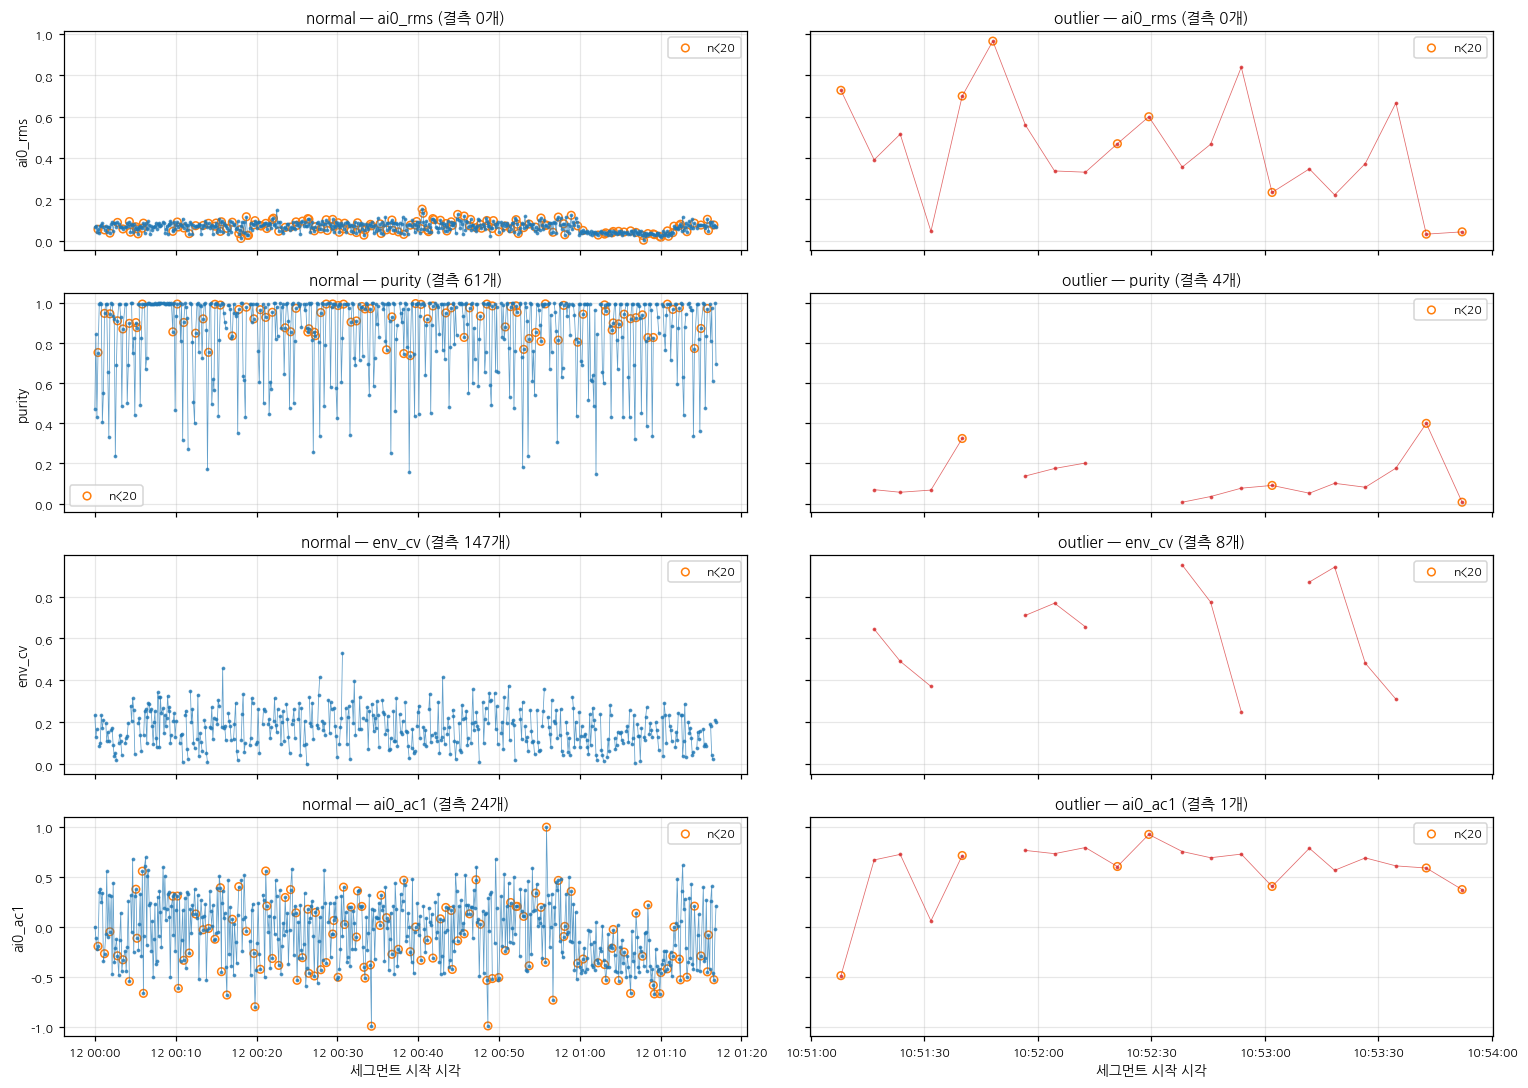

In [4]:
fig, axes = plt.subplots(4, 2, figsize=(14, 10), sharex="col", sharey="row")
for j, label in enumerate(["normal", "outlier"]):
    sub = F[F.label == label].sort_values("t_start")
    for i, feat in enumerate(EDA_FEATURES):
        ax = axes[i, j]
        ax.plot(sub.t_start, sub[feat], ".-", color=COLOR[label], ms=3, lw=.5, alpha=.7)
        short = (sub.n < 20) & sub[feat].notna()
        ax.scatter(sub.loc[short, "t_start"], sub.loc[short, feat],
                   facecolors="none", edgecolors="#ff7f0e", s=25, label="n<20")
        ax.set_title(f"{label} — {feat} (결측 {sub[feat].isna().sum()}개)")
        if j == 0: ax.set_ylabel(feat)
        ax.legend()
    axes[-1, j].set_xlabel("세그먼트 시작 시각")
plt.tight_layout(); plt.show()


### 1-1. 길이별 지표 분포·계산 가능 건수

짧은 세그먼트의 정보 부족과 실제 파형 변화를 구분한다.
결측은 정상값 0으로 채우지 않는다. 표는 필요할 때만 표시한다.


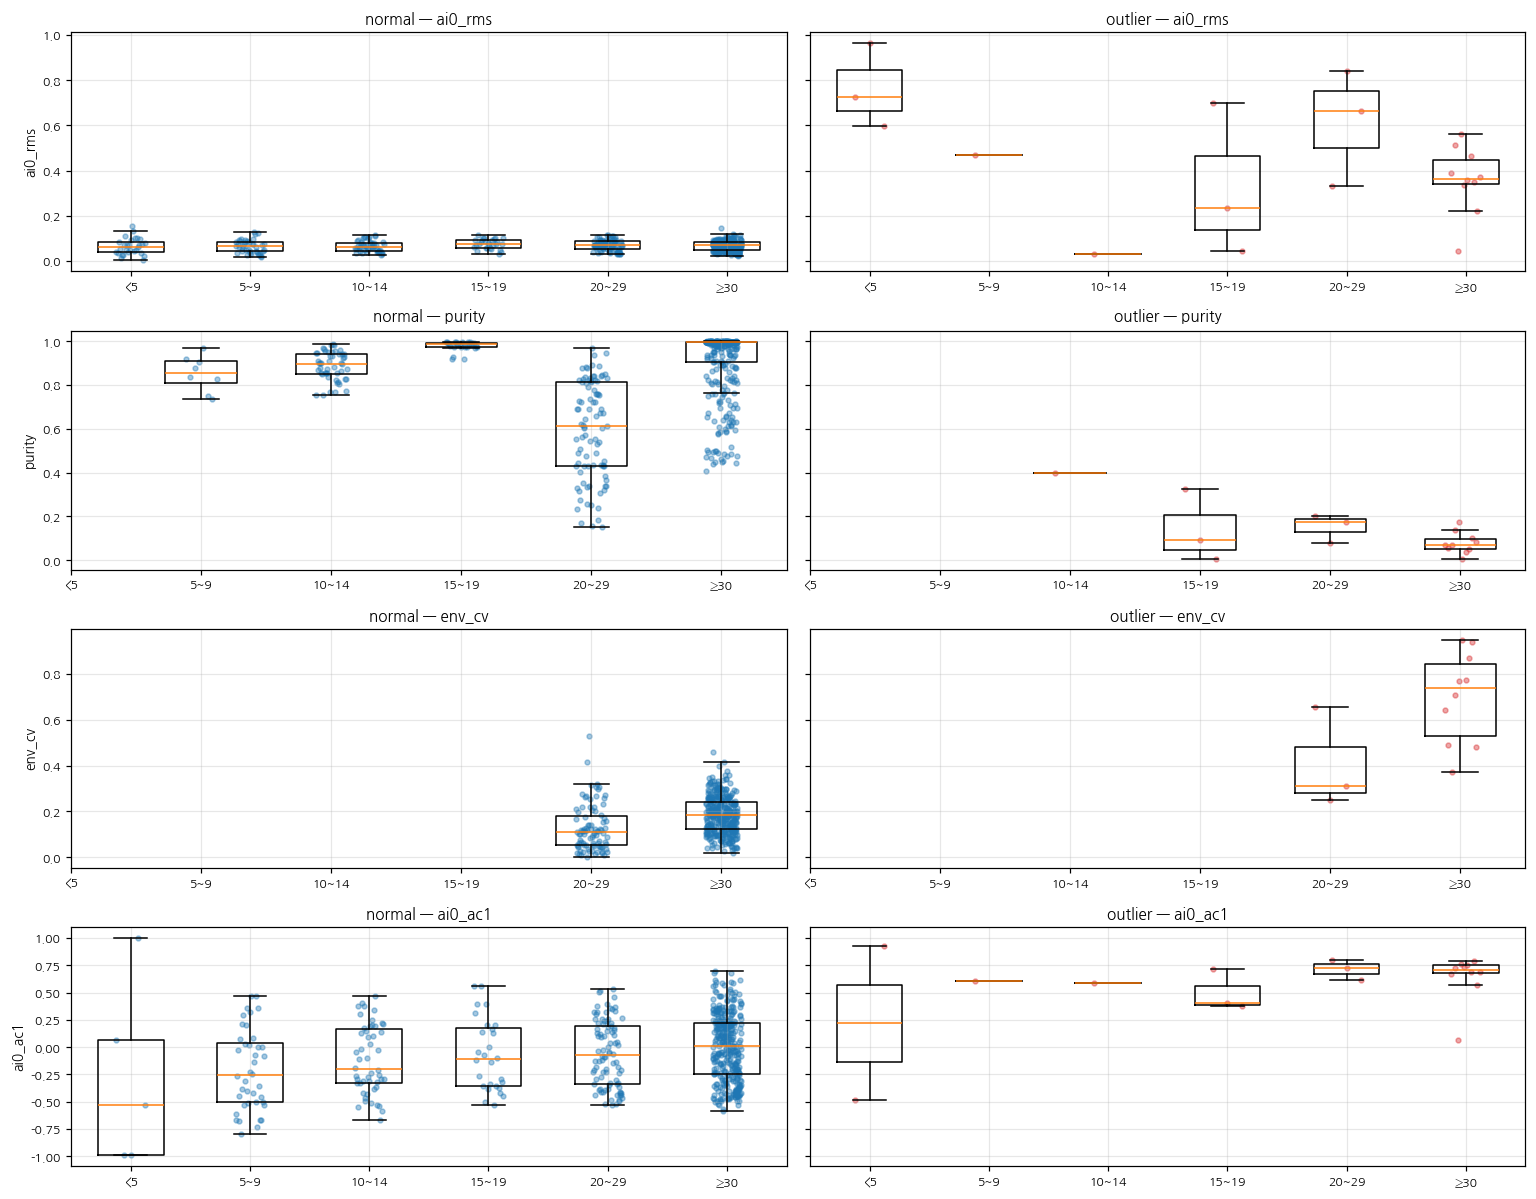

In [5]:
coverage = []
for (label, length), sub in F.groupby(["label", "length_bin"], observed=False):
    for feat in EDA_FEATURES:
        valid = sub[feat].notna().sum()
        coverage.append({"label": label, "길이": length, "지표": feat,
                         "전체": len(sub), "계산가능": valid, "결측": len(sub)-valid,
                         "중앙값": sub[feat].median()})
display_table(pd.DataFrame(coverage).round(4))
fig, axes = plt.subplots(4, 2, figsize=(14, 11), sharey="row")
for j, label in enumerate(["normal", "outlier"]):
    sub = F[F.label == label]
    for i, feat in enumerate(EDA_FEATURES):
        ax = axes[i, j]
        for pos, length in enumerate(LENGTH_LABELS):
            values = sub.loc[sub.length_bin == length, feat].dropna().to_numpy()
            if len(values):
                ax.boxplot([values], positions=[pos], widths=.55, showfliers=False)
                ax.scatter(pos + np.linspace(-.12, .12, len(values)), values,
                           s=10, alpha=.4, color=COLOR[label])
        ax.set_xticks(range(len(LENGTH_LABELS)), LENGTH_LABELS)
        ax.set_title(f"{label} — {feat}")
        if j == 0: ax.set_ylabel(feat)
plt.tight_layout(); plt.show()


## 2. 세그먼트별 FFT — 채널별 주파수 구조

전류·상부 진동·하부 진동을 각각 분석한다. 10Hz 샘플링의 관측 가능 범위는 **0~5Hz**이며,
고주파 성분의 실제 물리 주파수는 이 데이터만으로 복원하지 않는다.

평균 제거 후 직사각 창의 단측 파워 스펙트럼을 계산한다. 창·zero padding을 추가하지 않고
실제 FFT bin을 표시한다. 주파수 간격은 `FS/n`으로 짧은 세그먼트일수록 거칠다.
파워 합은 평균 제거 신호의 평균 제곱과 일치한다. 상대 파워는 비DC 전체 파워에 대한 비율이다.
n=1 또는 변동이 없는 신호에는 주파수 구조를 정의하지 않는다.

고정 구간 `(0,1]`, `(1,2]`, `(2,3]`, `(3,4]`, `(4,5]Hz`로 상대 파워를 집계하되,
FFT bin이 없는 구간은 결측으로 표시한다. 낮은 해상도의 세그먼트에서 대역이 비었다는 것은
그 주파수 성분이 없다는 뜻이 아니다. 세그먼트 간 신호를 이어 붙이지 않는다.


In [6]:
FFT_CHANNELS = ["AI2_Current", "AI0_Vibration", "AI1_Vibration"]
FFT_BANDS = [(0, 1), (1, 2), (2, 3), (3, 4), (4, 5)]
fft_rows, fft_summary = [], []
for label, sdf in SEG.items():
    for sid, g in sdf.groupby("seg_id"):
        size = len(g)
        for channel in FFT_CHANNELS:
            x = g[channel].to_numpy(dtype=float)
            centered = x - x.mean()
            freqs = np.fft.rfftfreq(size, d=1/FS)
            power = np.abs(np.fft.rfft(centered))**2 / size**2
            if size % 2 == 0:
                power[1:-1] *= 2
            else:
                power[1:] *= 2
            non_dc = freqs > 0
            total = power[non_dc].sum()
            usable = size > 1 and total > 0
            peak_idx = np.argmax(power[1:]) + 1 if usable else None
            row = {"label": label, "seg_id": sid, "n": size,
                   "t_start": g.TimeStamp.iloc[0], "channel": channel,
                   "df_hz": FS/size, "ac_power": total,
                   "peak_hz": freqs[peak_idx] if usable else np.nan,
                   "peak_share": power[peak_idx]/total if usable else np.nan}
            for lower, upper in FFT_BANDS:
                mask = (freqs > lower) & (freqs <= upper)
                row[f"({lower},{upper}]Hz"] = power[mask].sum()/total if usable and mask.any() else np.nan
            fft_summary.append(row)
            for idx in np.flatnonzero(non_dc):
                fft_rows.append({"label": label, "seg_id": sid, "n": size,
                                 "t_start": g.TimeStamp.iloc[0], "channel": channel,
                                 "frequency_hz": freqs[idx], "power": power[idx],
                                 "relative_power": power[idx]/total if usable else np.nan})
FFT = pd.DataFrame(fft_rows)
FFT_SEG = pd.DataFrame(fft_summary)
FFT_SEG["length_bin"] = pd.cut(FFT_SEG.n, [0,5,10,15,20,30,np.inf],
                               labels=LENGTH_LABELS, right=False)
print("세그먼트별 주파수 요약")
display_table(FFT_SEG.round(4))
print("라벨·채널별 FFT 해상도 및 지배 주파수 요약")
display_table(FFT_SEG.groupby(["label", "channel"])[["df_hz", "peak_hz", "peak_share", "ac_power"]].describe().round(4))


세그먼트별 주파수 요약
라벨·채널별 FFT 해상도 및 지배 주파수 요약


### 2-1. 시간에 따른 주파수 분포와 지배 주파수

위쪽은 각 세그먼트의 **실제 FFT bin**을 시작 시각에 배치한 상대 파워 지도다.
색은 세그먼트 내 상대 파워이며 세그먼트 사이 시간 공백은 보간하지 않는다.
아래쪽은 지배 bin 주파수다. n<20은 별도로 표시하여 시간 변화와 길이 영향을 함께 확인한다.


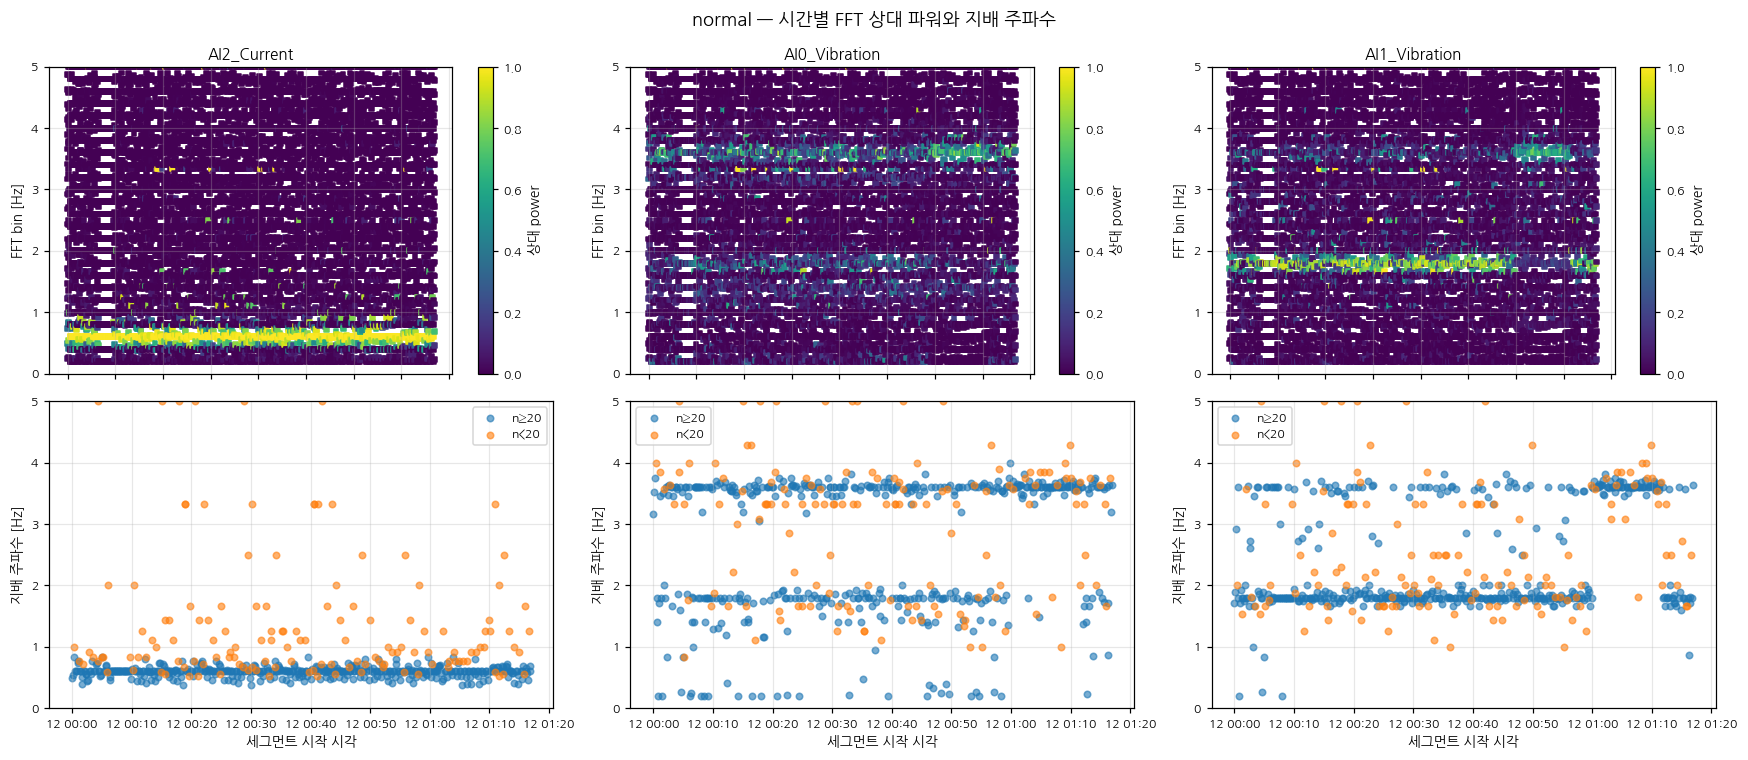

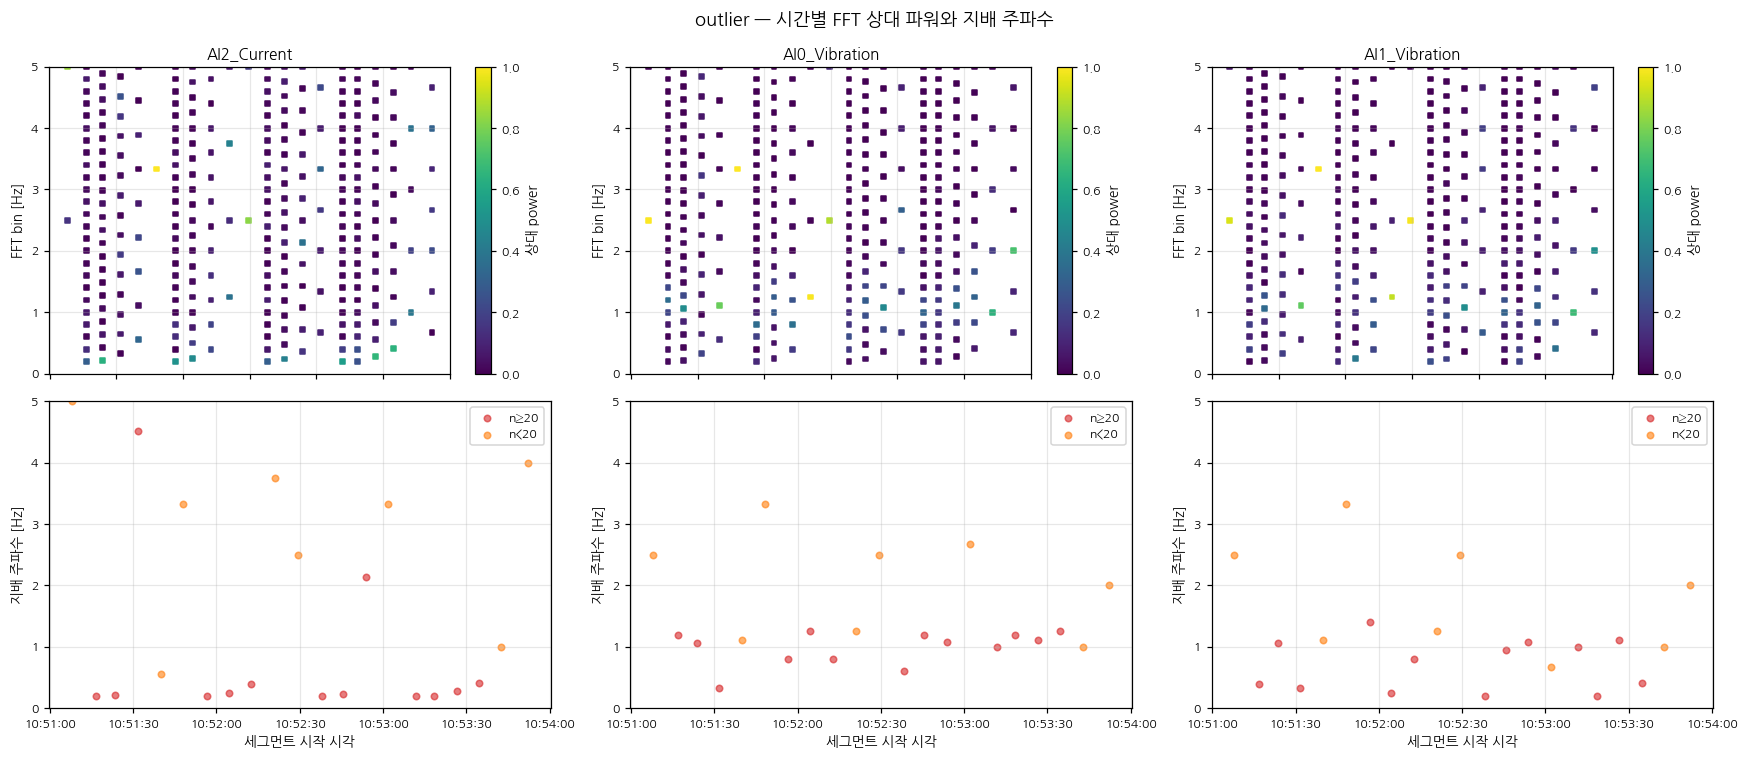

In [7]:
for label in ["normal", "outlier"]:
    fig, axes = plt.subplots(2, 3, figsize=(16, 7), sharex="col")
    for j, channel in enumerate(FFT_CHANNELS):
        bins = FFT[(FFT.label == label) & (FFT.channel == channel)].dropna(subset=["relative_power"])
        points = axes[0,j].scatter(bins.t_start, bins.frequency_hz, c=bins.relative_power,
                                   s=10, marker="s", cmap="viridis", vmin=0, vmax=1)
        axes[0,j].set_ylim(0,5); axes[0,j].set_ylabel("FFT bin [Hz]")
        axes[0,j].set_title(channel)
        fig.colorbar(points, ax=axes[0,j], label="相対 power".replace("相対", "상대"))
        sub = FFT_SEG[(FFT_SEG.label == label) & (FFT_SEG.channel == channel)]
        for short, color, name in [(False,COLOR[label],"n≥20"),(True,"#ff7f0e","n<20")]:
            picked = sub[(sub.n < 20) == short]
            axes[1,j].scatter(picked.t_start,picked.peak_hz,s=18,alpha=.6,color=color,label=name)
        axes[1,j].set_ylim(0,5); axes[1,j].set_ylabel("지배 주파수 [Hz]")
        axes[1,j].set_xlabel("세그먼트 시작 시각"); axes[1,j].legend()
    fig.suptitle(f"{label} — 시간별 FFT 상대 파워와 지배 주파수")
    plt.tight_layout(); plt.show()


### 2-2. 세그먼트 길이에 따른 주파수 구조

지배 주파수와 실제 길이를 함께 표시하고 길이별 고정 대역 상대 파워를 요약한다.
대역 평균에는 해당 대역에 FFT bin이 있는 세그먼트만 포함하며, 유효 건수도 함께 표시한다.
길이 때문에 지배 주파수가 특정 격자에 모이는 현상을 실제 주파수 변화와 구분해야 한다.


길이별 주파수·해상도 요약
길이별 대역 상대 파워 (유효 건수와 평균)


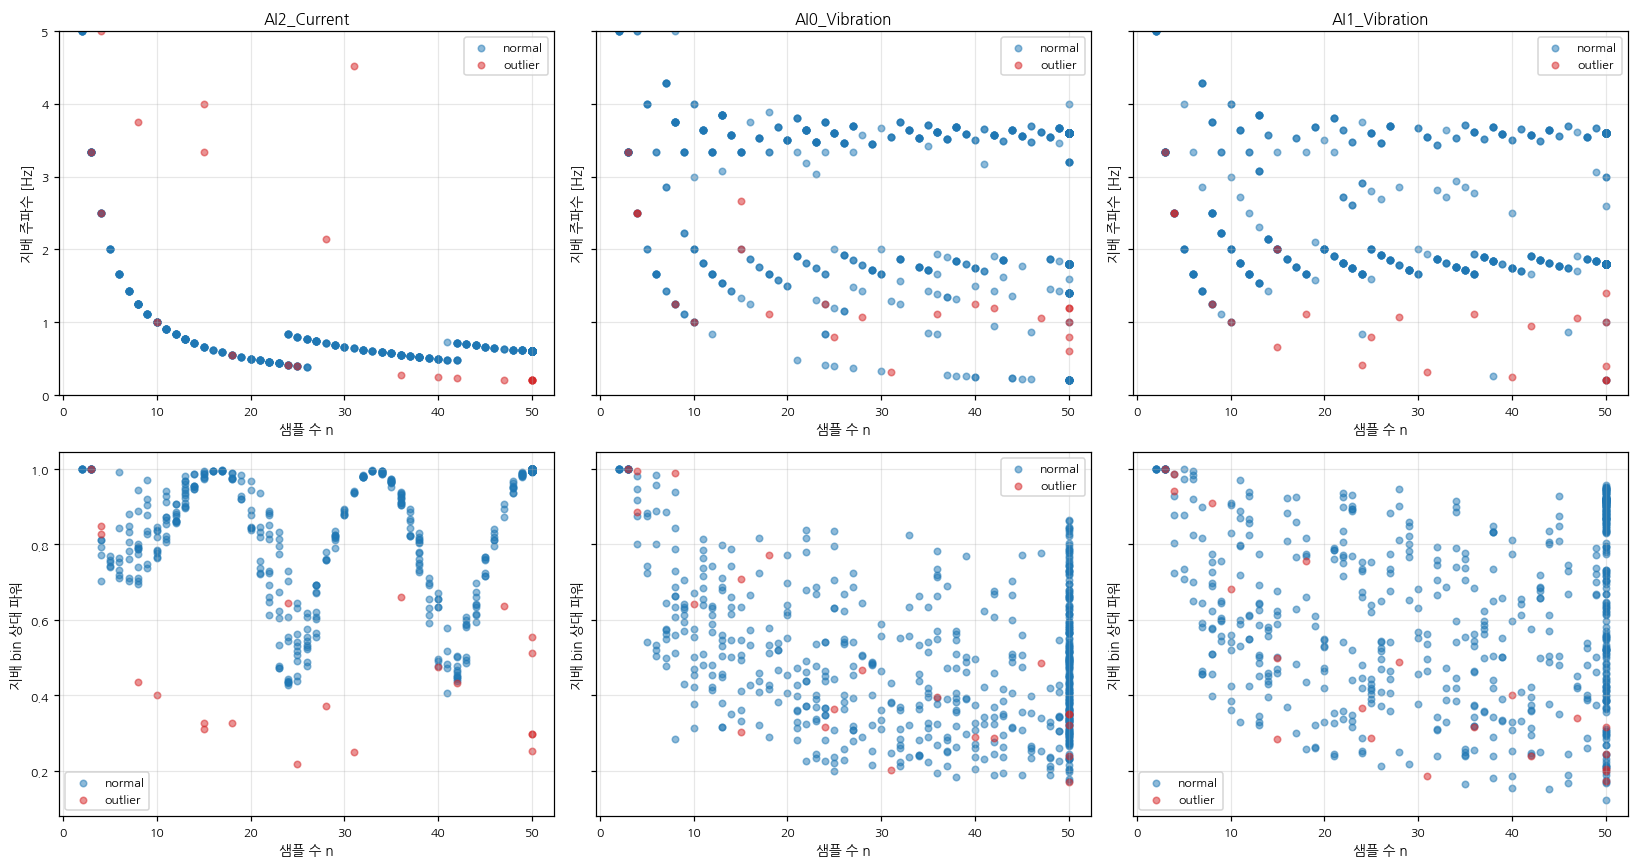

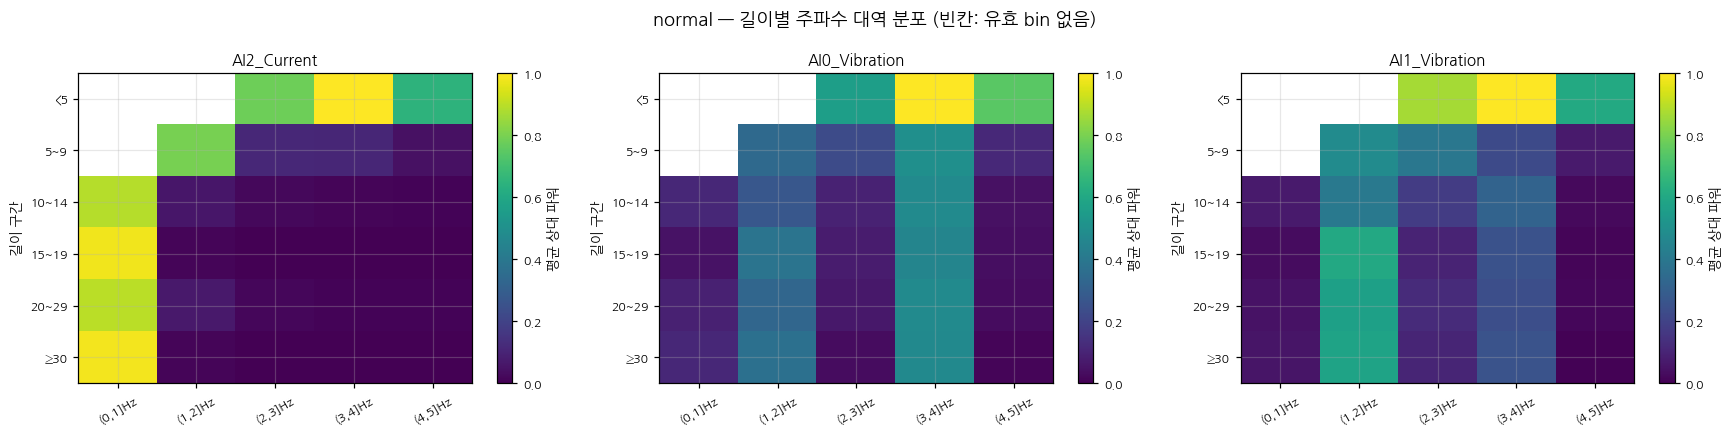

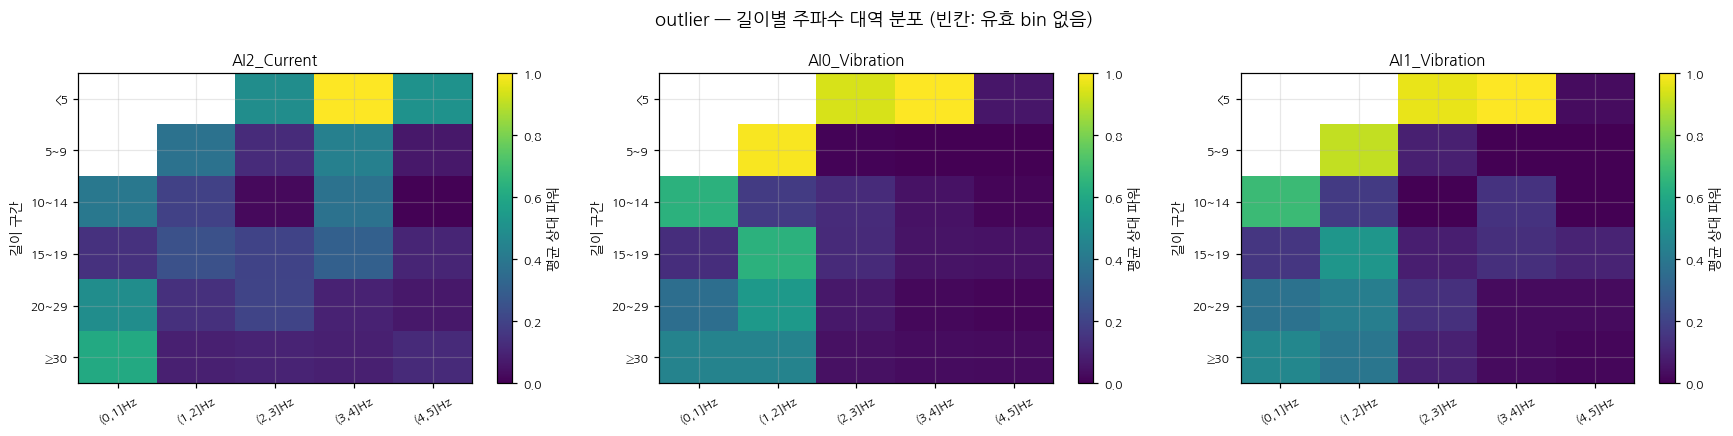

In [8]:
fig, axes = plt.subplots(2,3,figsize=(15,8),sharey="row")
for j, channel in enumerate(FFT_CHANNELS):
    for label in ["normal","outlier"]:
        sub=FFT_SEG[(FFT_SEG.channel==channel)&(FFT_SEG.label==label)]
        axes[0,j].scatter(sub.n,sub.peak_hz,s=18,alpha=.5,color=COLOR[label],label=label)
        axes[1,j].scatter(sub.n,sub.peak_share,s=18,alpha=.5,color=COLOR[label],label=label)
    axes[0,j].set_title(channel); axes[0,j].set_ylim(0,5)
    axes[0,j].set_ylabel("지배 주파수 [Hz]"); axes[1,j].set_ylabel("지배 bin 상대 파워")
    for ax in axes[:,j]: ax.set_xlabel("샘플 수 n"); ax.legend()
plt.tight_layout(); plt.show()
band_columns=[f"({lo},{hi}]Hz" for lo,hi in FFT_BANDS]
print("길이별 주파수·해상도 요약")
display_table(FFT_SEG.groupby(["label","channel","length_bin"],observed=True)[
    ["n","df_hz","peak_hz","peak_share"]].agg(["count","median"]).round(3))
print("길이별 대역 상대 파워 (유효 건수와 평균)")
display_table(FFT_SEG.groupby(["label","channel","length_bin"],observed=True)[band_columns].agg(["count","mean"]).round(3))
for label in ["normal","outlier"]:
    fig,axes=plt.subplots(1,3,figsize=(16,4))
    for ax,channel in zip(axes,FFT_CHANNELS):
        sub=FFT_SEG[(FFT_SEG.label==label)&(FFT_SEG.channel==channel)]
        matrix=sub.groupby("length_bin",observed=False)[band_columns].mean().reindex(LENGTH_LABELS)
        plot=ax.imshow(np.ma.masked_invalid(matrix.to_numpy()),aspect="auto",vmin=0,vmax=1,cmap="viridis")
        ax.set_xticks(range(5),band_columns,rotation=30); ax.set_yticks(range(6),LENGTH_LABELS)
        ax.set_title(channel); ax.set_ylabel("길이 구간")
        fig.colorbar(plot,ax=ax,label="평균 상대 파워")
    fig.suptitle(f"{label} — 길이별 주파수 대역 분포 (빈칸: 유효 bin 없음)")
    plt.tight_layout(); plt.show()


### 2-3. 대표 원시 파형과 FFT

출력이 과도해지지 않도록 10~14와 30 이상 길이에서 각 파일의 가운데 세그먼트를 비교한다.
전체 길이의 주파수 구조는 앞의 시간·길이별 그래프에서 확인한다.
단측 파워 합은 평균 제거 신호의 RMS²이며, 상대 파워는 비DC 전체 파워에 대한 비율이다.


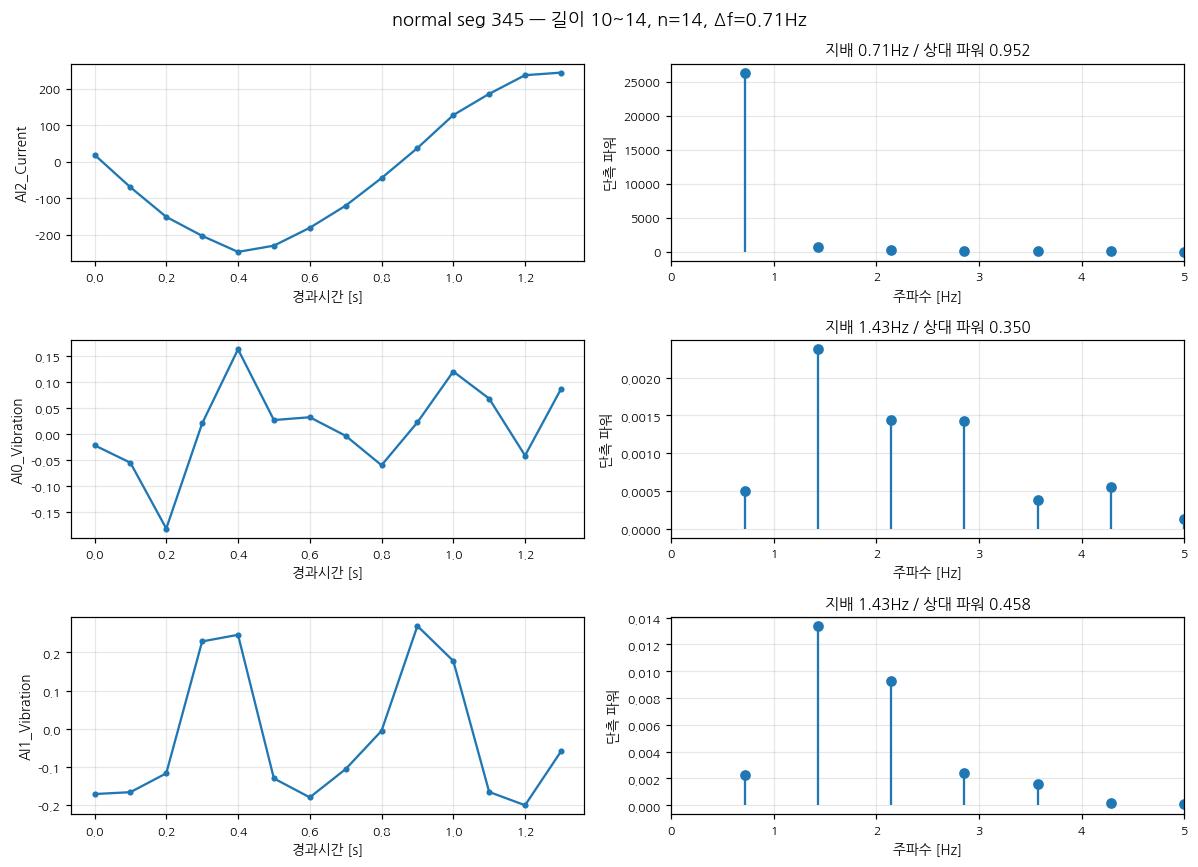

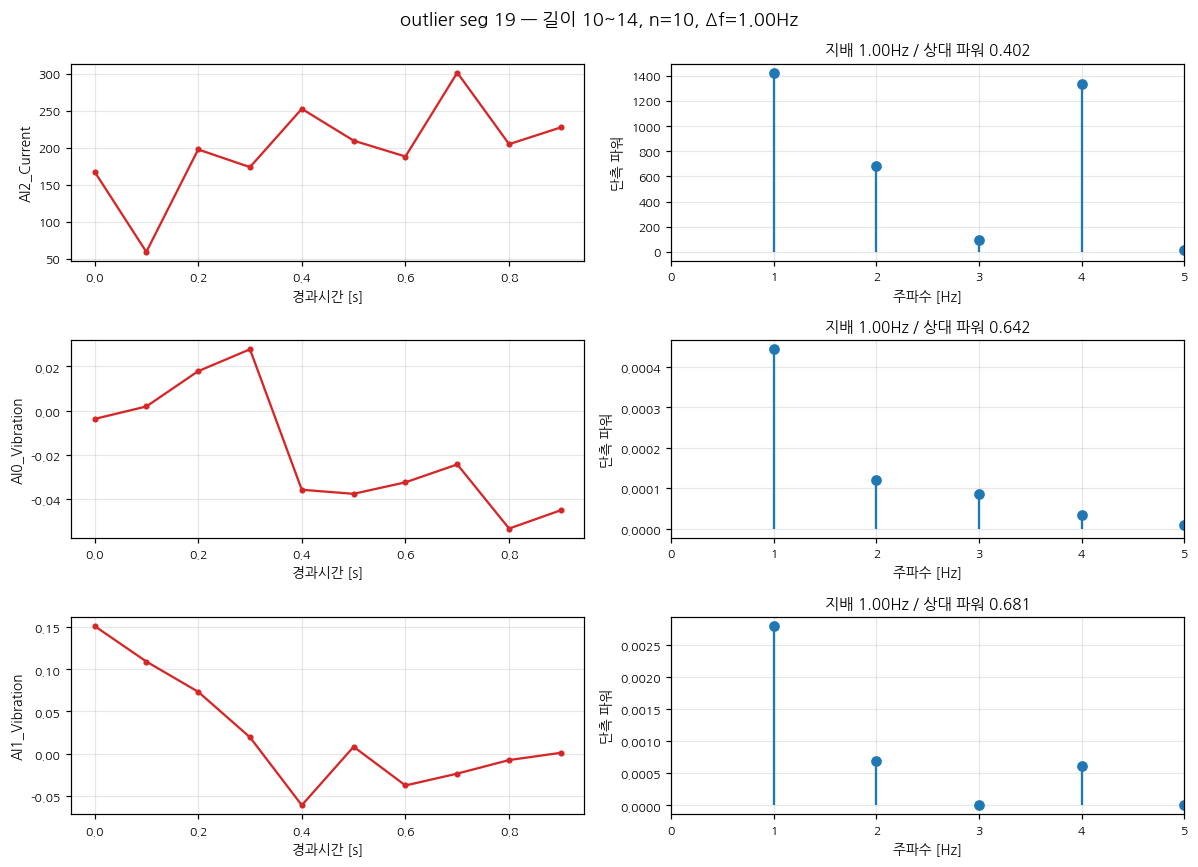

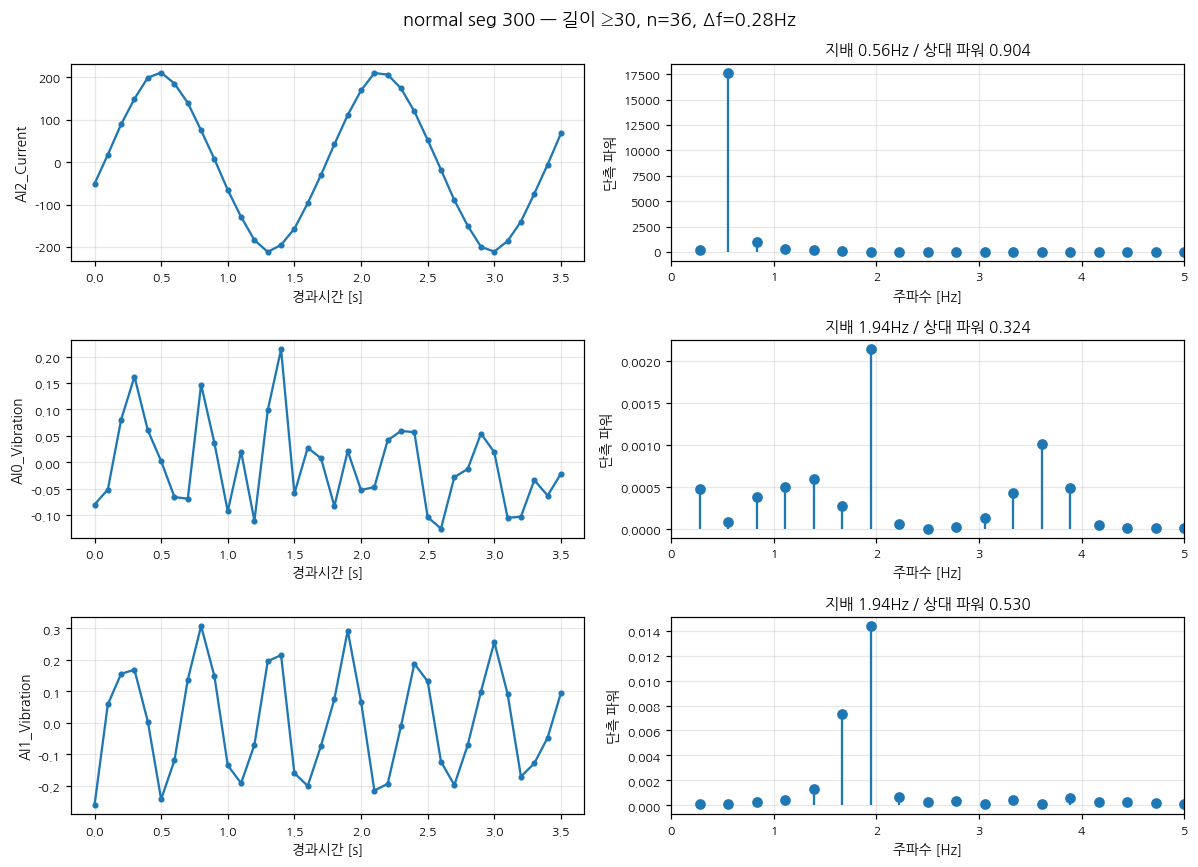

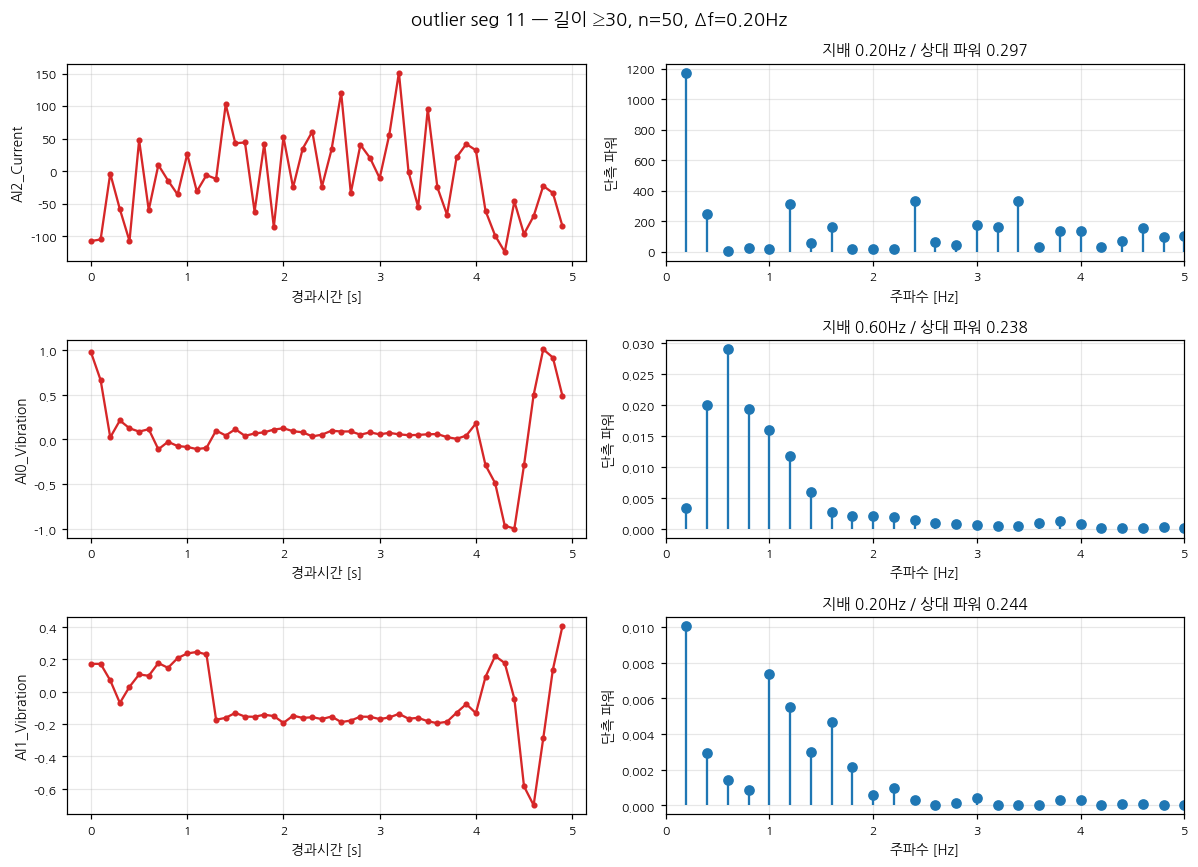

In [9]:
for length in ["10~14", "≥30"]:
    for label in ["normal","outlier"]:
        sub=F[(F.label==label)&(F.length_bin==length)].sort_values("t_start")
        if sub.empty: continue
        row=sub.iloc[len(sub)//2]; sid=int(row.seg_id)
        g=SEG[label][SEG[label].seg_id==sid]
        fig,axes=plt.subplots(3,2,figsize=(11,8))
        for i,channel in enumerate(FFT_CHANNELS):
            axes[i,0].plot((g.TimeStamp-g.TimeStamp.iloc[0]).dt.total_seconds(),g[channel],"o-",ms=3,color=COLOR[label])
            axes[i,0].set_ylabel(channel); axes[i,0].set_xlabel("経過時間 [s]".replace("経過時間","경과시간"))
            bins=FFT[(FFT.label==label)&(FFT.seg_id==sid)&(FFT.channel==channel)]
            if not bins.empty:
                axes[i,1].stem(bins.frequency_hz,bins.power,basefmt=" ")
            else:
                axes[i,1].text(.5,.5,"FFT計算不可 (n=1)".replace("計算不可","계산 불가"),transform=axes[i,1].transAxes,ha="center")
            axes[i,1].set_xlim(0,5);axes[i,1].set_xlabel("주파수 [Hz]");axes[i,1].set_ylabel("단측 파워")
            info=FFT_SEG[(FFT_SEG.label==label)&(FFT_SEG.seg_id==sid)&(FFT_SEG.channel==channel)].iloc[0]
            axes[i,1].set_title(f"지배 {info.peak_hz:.2f}Hz / 상대 파워 {info.peak_share:.3f}")
        fig.suptitle(f"{label} seg {sid} — 길이 {length}, n={len(g)}, Δf={FS/len(g):.2f}Hz")
        plt.tight_layout();plt.show()


## 3. 정상 전류의 공통 주기 기준

정상 시간순 앞 70% 중 n≥30 세그먼트에서 주기 0.9~2.2초 범위의 사인파를 적합한다.
FFT bin에 제한하지 않고 연속 주파수를 탐색하여 주파수 중앙값을 공통 기준으로 사용한다.
기준을 추정할 때만 주파수를 조정하며, 아래 비교에서는 모든 세그먼트의 주파수를 고정한다.
현재 기준은 약 **0.6000Hz / 1.6666초**다. 실제 교류 전원 주파수를 복원한 값이 아니라
10Hz 데이터에서 관측되는 정상 기준 파형의 주기다.


In [10]:
from scipy.optimize import minimize_scalar

def fit_current_sine(g, frequency_bounds=None, fixed_frequency=None):
    x = g.AI2_Current.to_numpy(dtype=float)
    t = (g.TimeStamp - g.TimeStamp.iloc[0]).dt.total_seconds().to_numpy()
    def solve(freq):
        design = np.column_stack([np.cos(2*np.pi*freq*t), np.sin(2*np.pi*freq*t), np.ones(len(t))])
        coef, *_ = np.linalg.lstsq(design, x, rcond=None)
        pred = design @ coef
        return np.sum((x-pred)**2), coef, pred
    if fixed_frequency is not None:
        freq = fixed_frequency
    else:
        lo, hi = frequency_bounds
        grid = np.linspace(lo, hi, 401)
        errors = np.array([solve(freq)[0] for freq in grid])
        best = int(errors.argmin())
        left, right = grid[max(0,best-1)], grid[min(len(grid)-1,best+1)]
        refined = minimize_scalar(lambda f: solve(f)[0], bounds=(left,right), method="bounded")
        candidates = [grid[best], refined.x, lo, hi]
        freq = min(candidates, key=lambda f: solve(f)[0])
    ss, coef, pred = solve(freq)
    total = np.sum((x-x.mean())**2)
    return {"frequency_hz": freq, "period_s": 1/freq,
            "amplitude": np.hypot(coef[0],coef[1]), "offset": coef[2],
            "rmse": np.sqrt(ss/len(x)), "nrmse": np.sqrt(ss/total) if total>0 else np.nan,
            "r2": 1-ss/total if total>0 else np.nan, "pred": pred}

normal_time = F[F.label=="normal"].sort_values("t_start")
sine_split = normal_time.t_start.quantile(.70)
reference = normal_time[(normal_time.t_start<sine_split)&(normal_time.n>=30)]
broad_bounds = (1/2.2, 1/.9)
reference_rows = []
for row in reference.itertuples():
    g=SEG["normal"][SEG["normal"].seg_id==row.seg_id]
    fit=fit_current_sine(g, frequency_bounds=broad_bounds)
    reference_rows.append({"seg_id":row.seg_id, "n":row.n,
                           **{key:value for key,value in fit.items() if key!="pred"}})
SINE_REF=pd.DataFrame(reference_rows)
f_reference=SINE_REF.frequency_hz.median()
f_lower,f_upper=SINE_REF.frequency_hz.quantile([.05,.95]).to_numpy()
if f_upper-f_lower<1e-6:
    f_lower,f_upper=f_reference-1e-6,f_reference+1e-6
print(f"基準 normal train n≥30: {len(SINE_REF)}個".replace("基準","기준").replace("個","개"))
print(f"공통 주파수 {f_reference:.4f}Hz / 주기 {1/f_reference:.4f}s")
print(f"정상 기준 주파수 5~95% 범위 {f_lower:.4f}~{f_upper:.4f}Hz")
print(f"기준 세그먼트 적합 R² 중앙값 {SINE_REF.r2.median():.4f}, 최솟값 {SINE_REF.r2.min():.4f}")



기준 normal train n≥30: 249개
공통 주파수 0.6000Hz / 주기 1.6666s
정상 기준 주파수 5~95% 범위 0.5973~0.6028Hz
기준 세그먼트 적합 R² 중앙값 0.9972, 최솟값 0.9943


## 4. 정상 기준 중심·진폭을 고정한 전류 파형과 비교

기존 적합은 세그먼트마다 진폭·위상·중심값을 조정했다. 짧은 조각에서 자유로운 중심 이동으로
잔차가 작아지는지 확인하기 위해, 긴 정상 train의 사인 적합에서 중심값·진폭 중앙값을 추정한다.
짧은 세그먼트의 표본 평균을 빼지는 않는다. 부분 주기의 평균은 파형의 실제 중심과 다르다.

모든 모델에서 주기는 기존 공통 기준으로 고정한다.

| 모델 | 세그먼트마다 허용하는 값 |
|---|---|
| 기존 자유 적합 | 진폭·위상·중심값 |
| 정상 중심 고정 | 진폭·위상 (중심은 정상 train 기준) |
| 영점 고정 | 진폭·위상 (중심 0) |
| 정상 기준 파형 | 위상만 (진폭·중심 모두 정상 train 기준) |

위상은 취득 시작 위치가 다르므로 조정한다. 정상 진폭도 부하에 따라 달라지므로,
진폭까지 고정한 모델의 큰 잔차는 파형 왜곡과 진폭 차이를 함께 반영한다.
기준값은 정상 train n≥30에서만 구하며 다른 세그먼트를 보고 다시 정하지 않는다.


정상 기준: 주기 1.6666s, 중심 0.5489, 진폭 158.3520
정상 train 중심값 5/50/95%: {0.05: -0.1084, 0.5: 0.5489, 0.95: 1.1825}
정상 train 진폭 5/50/95%: {0.05: 114.5879, 0.5: 158.352, 0.95: 250.8284}
길이별 비교는 CENTER_SUMMARY 에 저장


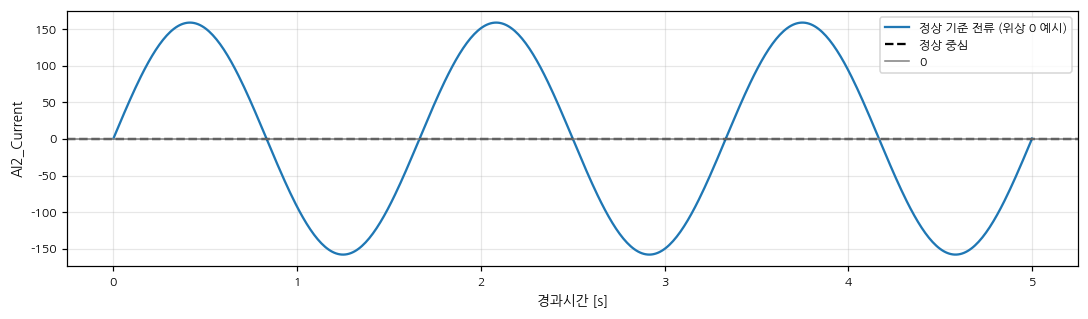

In [11]:
from scipy.optimize import minimize_scalar

# 기존 SINE_REF는 주파수도 조정했으므로 공통 주기 고정 상태에서 기준을 다시 계산한다.
center_reference_rows = []
for row in reference.itertuples():
    g = SEG["normal"].loc[SEG["normal"].seg_id == row.seg_id]
    fit = fit_current_sine(g, fixed_frequency=f_reference)
    center_reference_rows.append({"seg_id": row.seg_id, "offset": fit["offset"],
                                  "amplitude": fit["amplitude"]})
CENTER_REFERENCE = pd.DataFrame(center_reference_rows)
normal_center = CENTER_REFERENCE.offset.median()
normal_amplitude = CENTER_REFERENCE.amplitude.median()
print(f"정상 기준: 주기 {1/f_reference:.4f}s, 중심 {normal_center:.4f}, 진폭 {normal_amplitude:.4f}")
print("정상 train 중심값 5/50/95%:", CENTER_REFERENCE.offset.quantile([.05,.5,.95]).round(4).to_dict())
print("정상 train 진폭 5/50/95%:", CENTER_REFERENCE.amplitude.quantile([.05,.5,.95]).round(4).to_dict())

fig, ax = plt.subplots(figsize=(10,3))
reference_t = np.linspace(0, 3/f_reference, 500)
ax.plot(reference_t, normal_center + normal_amplitude*np.sin(2*np.pi*f_reference*reference_t),
        label="정상 기준 전류 (위상 0 예시)")
ax.axhline(normal_center, color="black", ls="--", label="정상 중심")
ax.axhline(0, color="gray", lw=1, label="0")
ax.set_xlabel("경과시간 [s]"); ax.set_ylabel("AI2_Current"); ax.legend()
plt.tight_layout(); plt.show()

def fit_centered_sine(g, center, amplitude=None):
    x = g.AI2_Current.to_numpy(dtype=float)
    t = (g.TimeStamp-g.TimeStamp.iloc[0]).dt.total_seconds().to_numpy()
    angle = 2*np.pi*f_reference*t
    if amplitude is None:
        design = np.column_stack([np.cos(angle), np.sin(angle)])
        coef, *_ = np.linalg.lstsq(design, x-center, rcond=None)
        pred = center + design@coef
    else:
        def loss(phase):
            pred = center + amplitude*np.sin(angle+phase)
            return np.sum((x-pred)**2)
        grid = np.linspace(-np.pi,np.pi,721)
        best = int(np.argmin([loss(phase) for phase in grid]))
        step = grid[1]-grid[0]
        phase = minimize_scalar(loss, bounds=(grid[best]-step,grid[best]+step), method="bounded").x
        pred = center + amplitude*np.sin(angle+phase)
    ss = np.sum((x-pred)**2)
    total = np.sum((x-x.mean())**2)
    return {"pred": pred, "rmse": np.sqrt(ss/len(x)),
            "nrmse": np.sqrt(ss/total) if total>0 else np.nan,
            "r2": 1-ss/total if total>0 else np.nan}

CENTER_MODELS = ["free", "normal_center", "zero_center", "normal_template"]
CENTER_LABELS = {"free":"기존 자유 적합",
                 "normal_center":"정상 중심 고정", "zero_center":"중심 0 고정",
                 "normal_template":"정상 진폭·중심 고정"}
CENTER_LABELS["free"] = "기존 자유 적합"
center_rows, CENTER_PRED = [], {}
for row in F.itertuples():
    g = SEG[row.label].loc[SEG[row.label].seg_id == row.seg_id]
    fits = {"free": fit_current_sine(g,fixed_frequency=f_reference),
            "normal_center": fit_centered_sine(g,normal_center),
            "zero_center": fit_centered_sine(g,0.0),
            "normal_template": fit_centered_sine(g,normal_center,normal_amplitude)}
    group = "outlier" if row.label=="outlier" else ("normal train" if row.t_start<sine_split else "normal test")
    for model, fit in fits.items():
        center_rows.append({"label":row.label,"group":group,"seg_id":row.seg_id,"n":row.n,
                            "t_start":row.t_start,"model":model,"rmse":fit["rmse"],
                            "nrmse":fit["nrmse"],"r2":fit["r2"]})
    CENTER_PRED[(row.label,row.seg_id)] = {model:fit["pred"] for model,fit in fits.items()}
CENTER_FIT = pd.DataFrame(center_rows)
CENTER_FIT["length_bin"] = pd.cut(CENTER_FIT.n,[0,4,6,8,11,15,20,30,np.inf],
                                  labels=["≤3","4~5","6~7","8~10","11~14","15~19","20~29","≥30"],right=False)
CENTER_SUMMARY = CENTER_FIT.groupby(["group","length_bin","model"],observed=True).agg(
    count=("seg_id","size"), median_nrmse=("nrmse","median"), median_r2=("r2","median"))
display_table(CENTER_SUMMARY.round(4))
print("長さ別比較は CENTER_SUMMARY に保存".replace("長さ別比較は","길이별 비교는").replace("に保存","에 저장"))


### 4-1. 길이별 적합 결과의 읽는 법

위쪽은 각 제약의 길이별 NRMSE 산점도이고, 아래는 정상 test·outlier의 시간순 처음·중간·끝
최대 3개씩이다. 모든 모델에서 주기는 같다. 낮은 잔차는 해당 정상 사인 형태와의 유사성을 뜻한다.
중심을 자유롭게 맞추면 짧은 조각이 잘 맞기 쉬우며, 정상 중심 고정이 그 효과를 줄이는지 확인한다.
n≤3의 자유 적합과 n≤2의 중심 고정 적합은 관측점을 그대로 통과할 수 있어 판별 근거로 쓰지 않는다.
제약 모델에서는 NRMSE>1 또는 R²<0도 가능하다. 이는 평균값 예측보다 오차가 크다는 의미다.
고정 진폭 모델은 형태와 진폭 차이를 함께 평가한다.


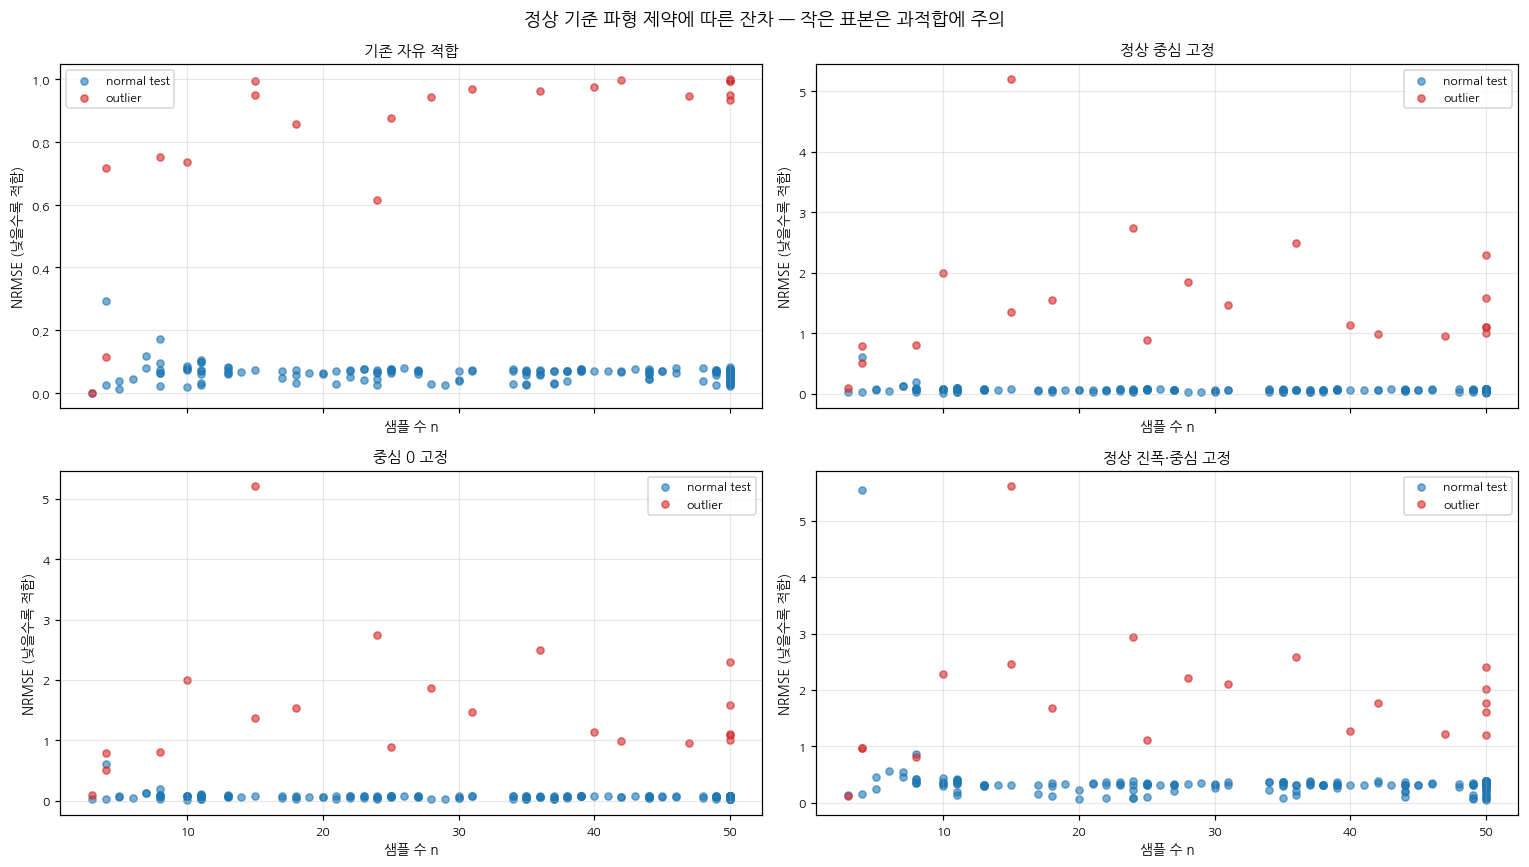

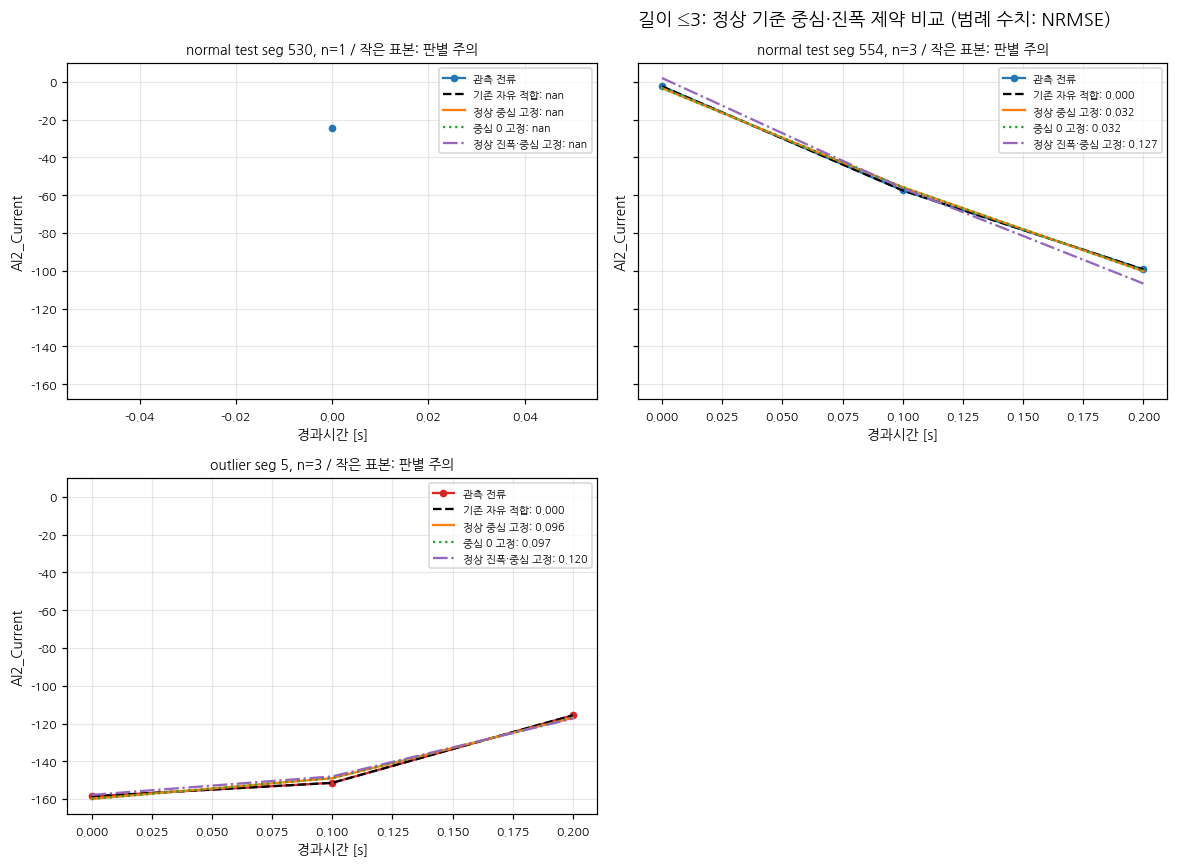

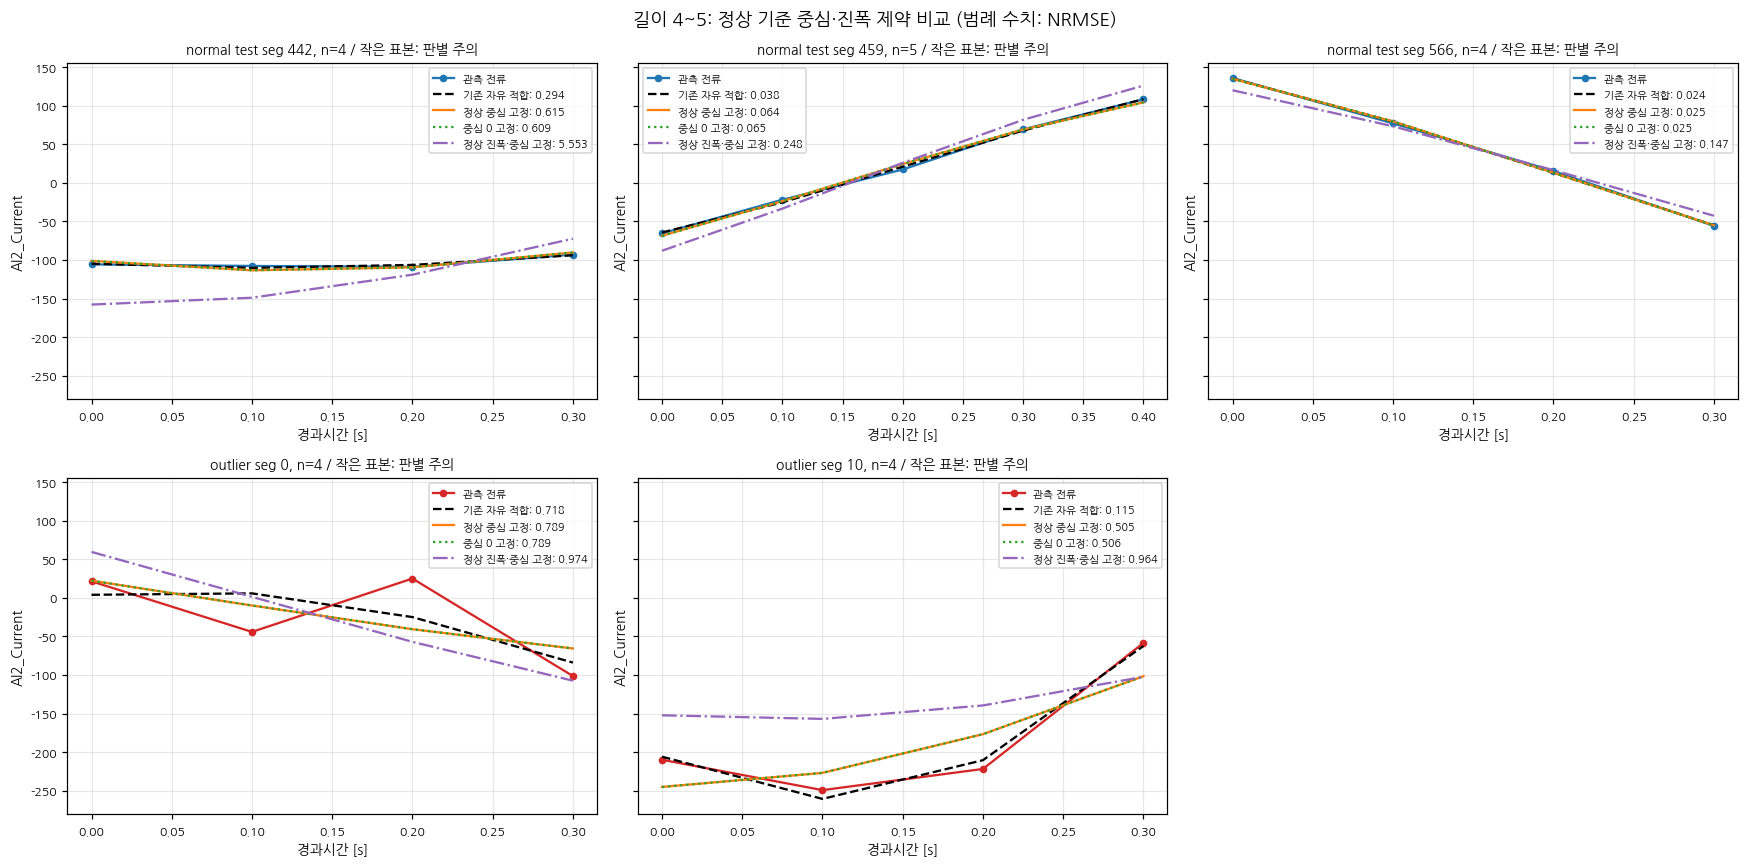

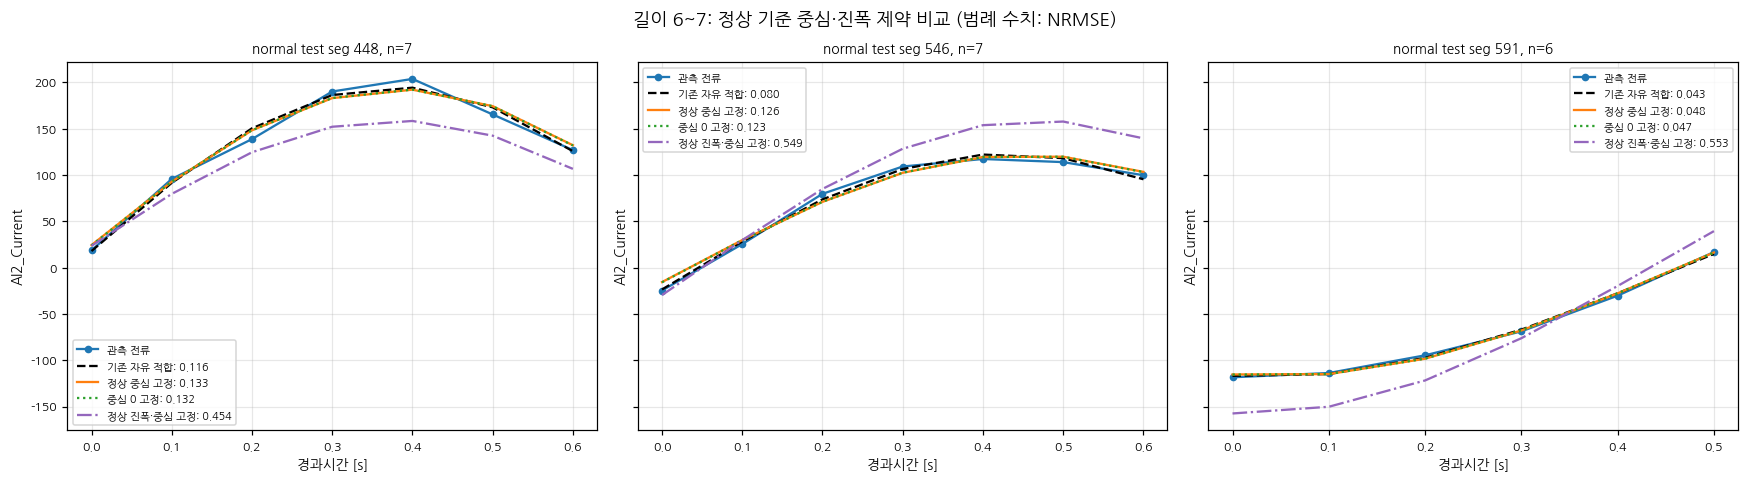

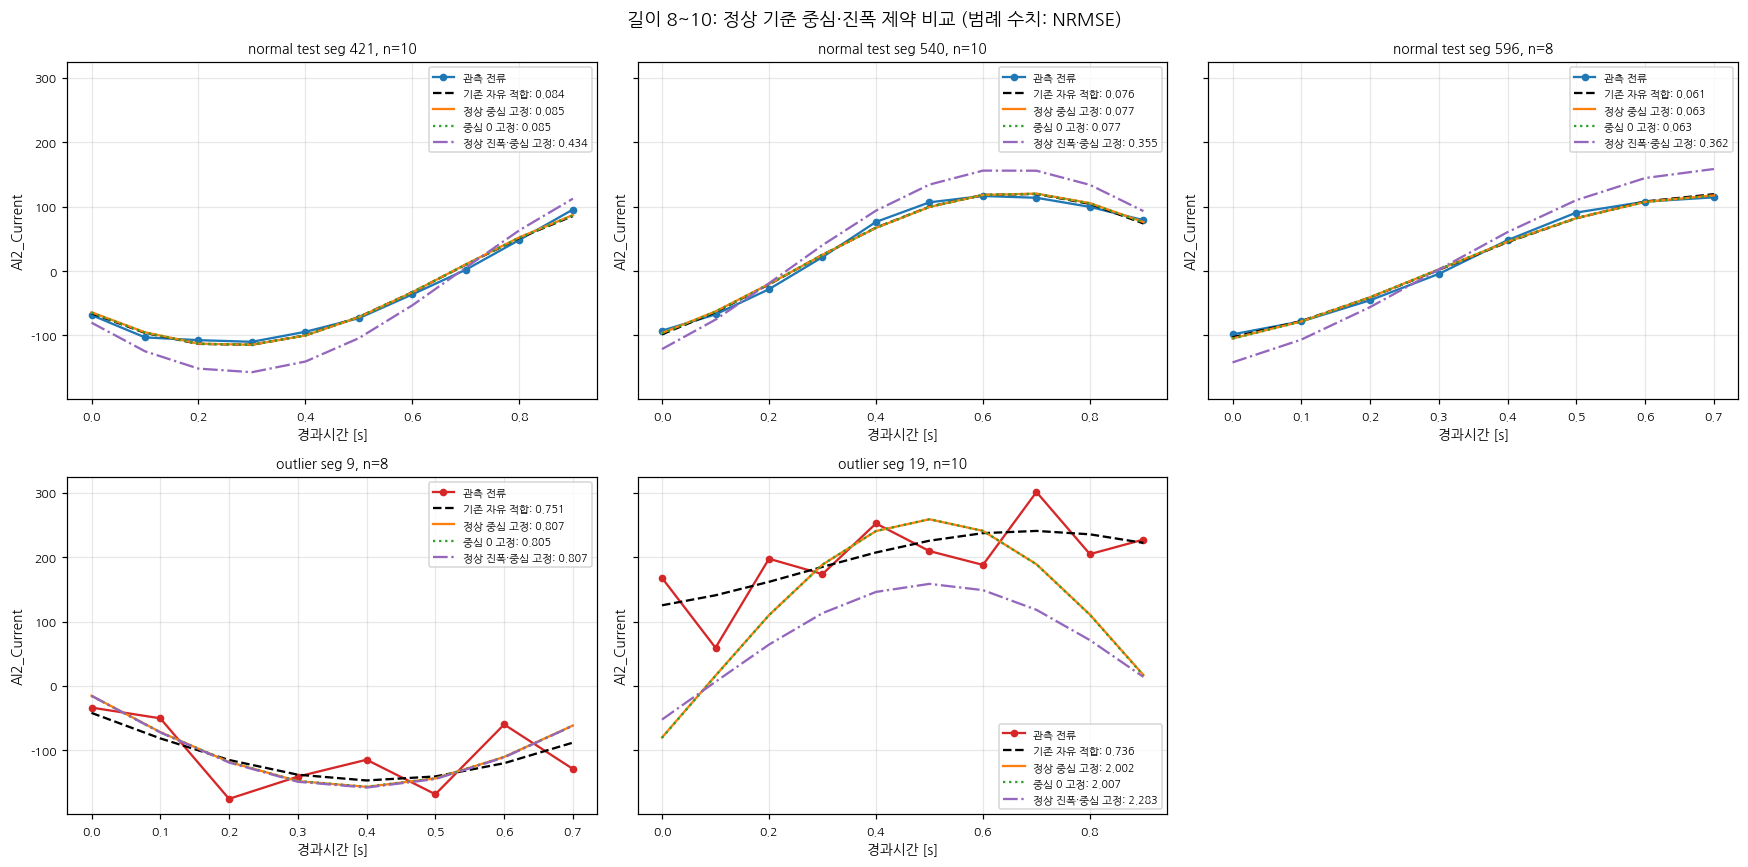

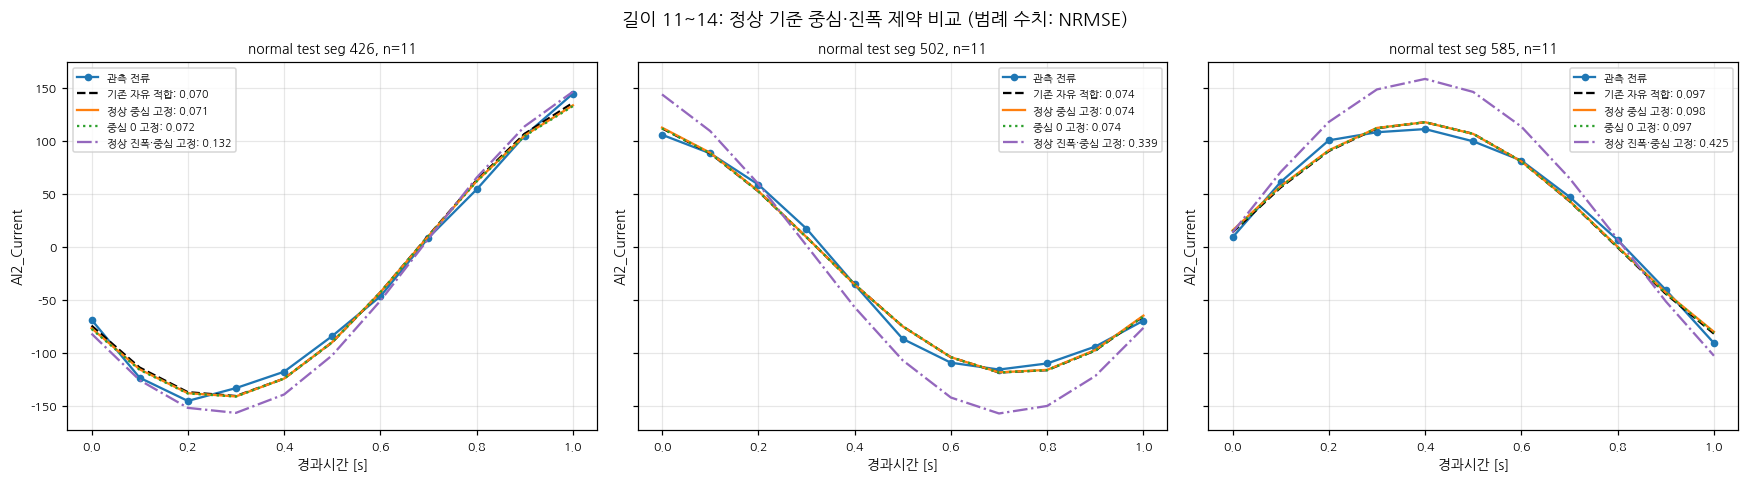

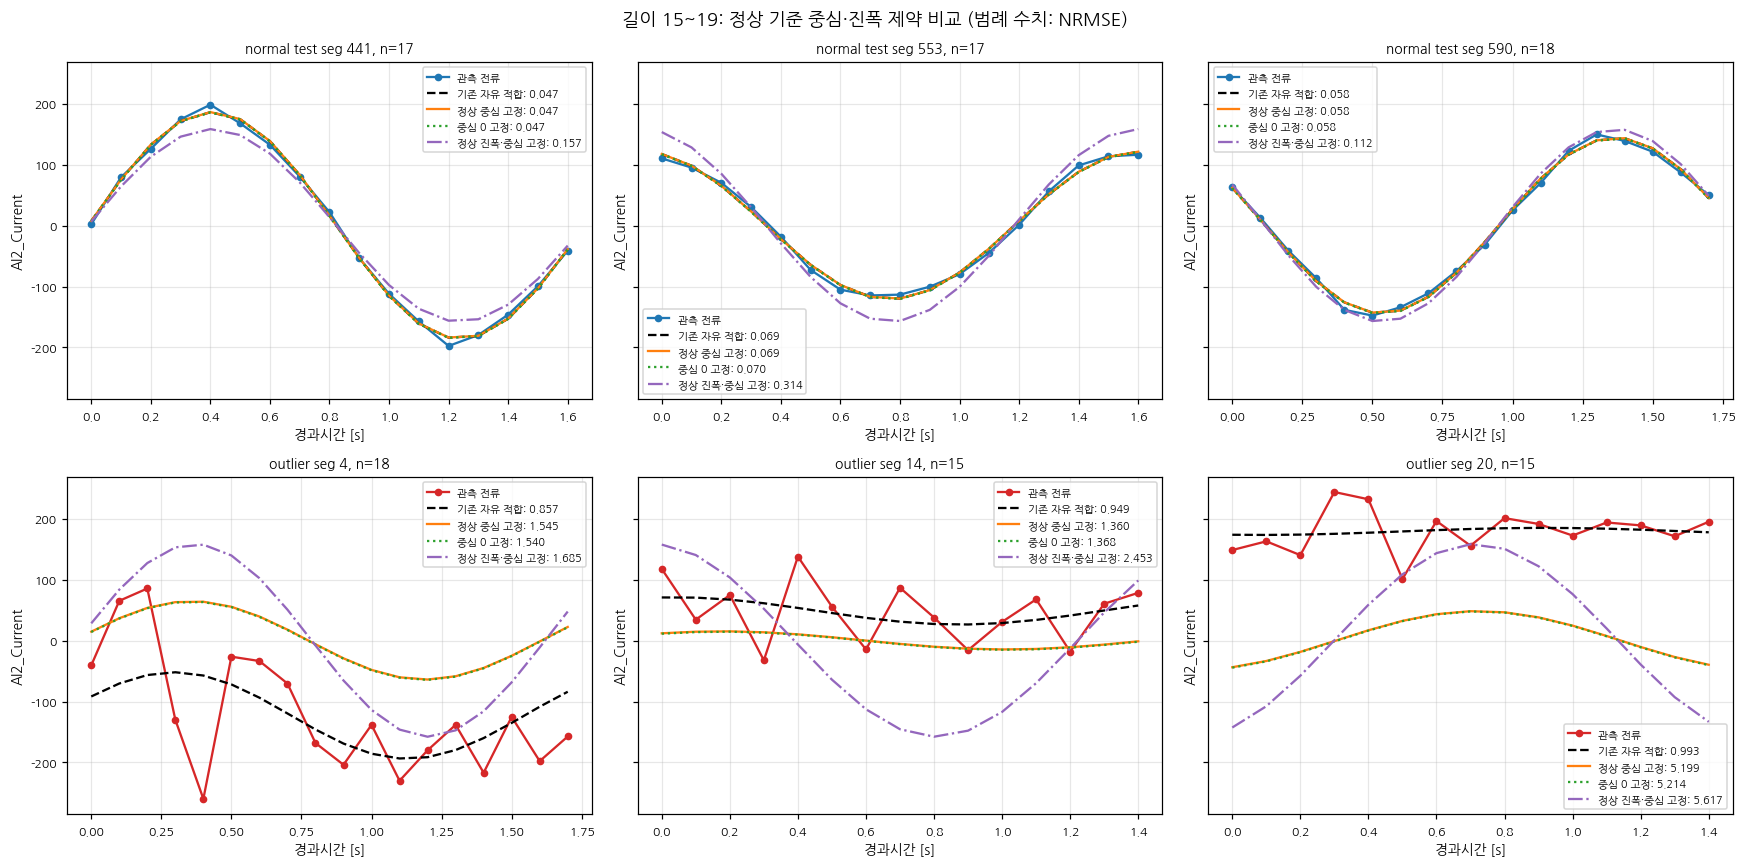

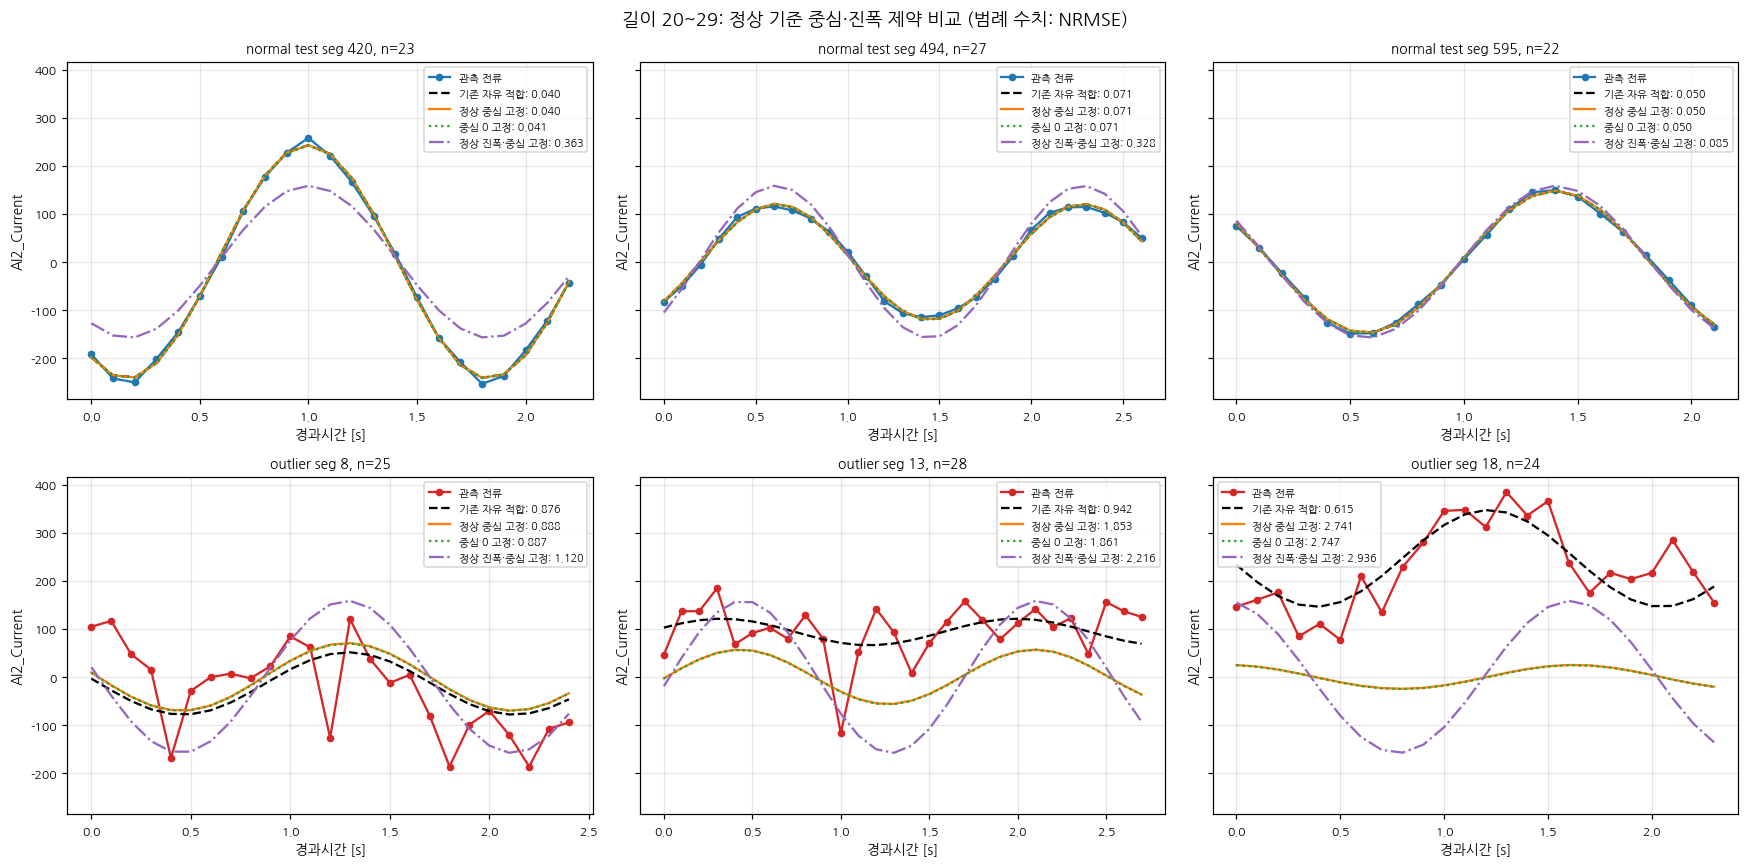

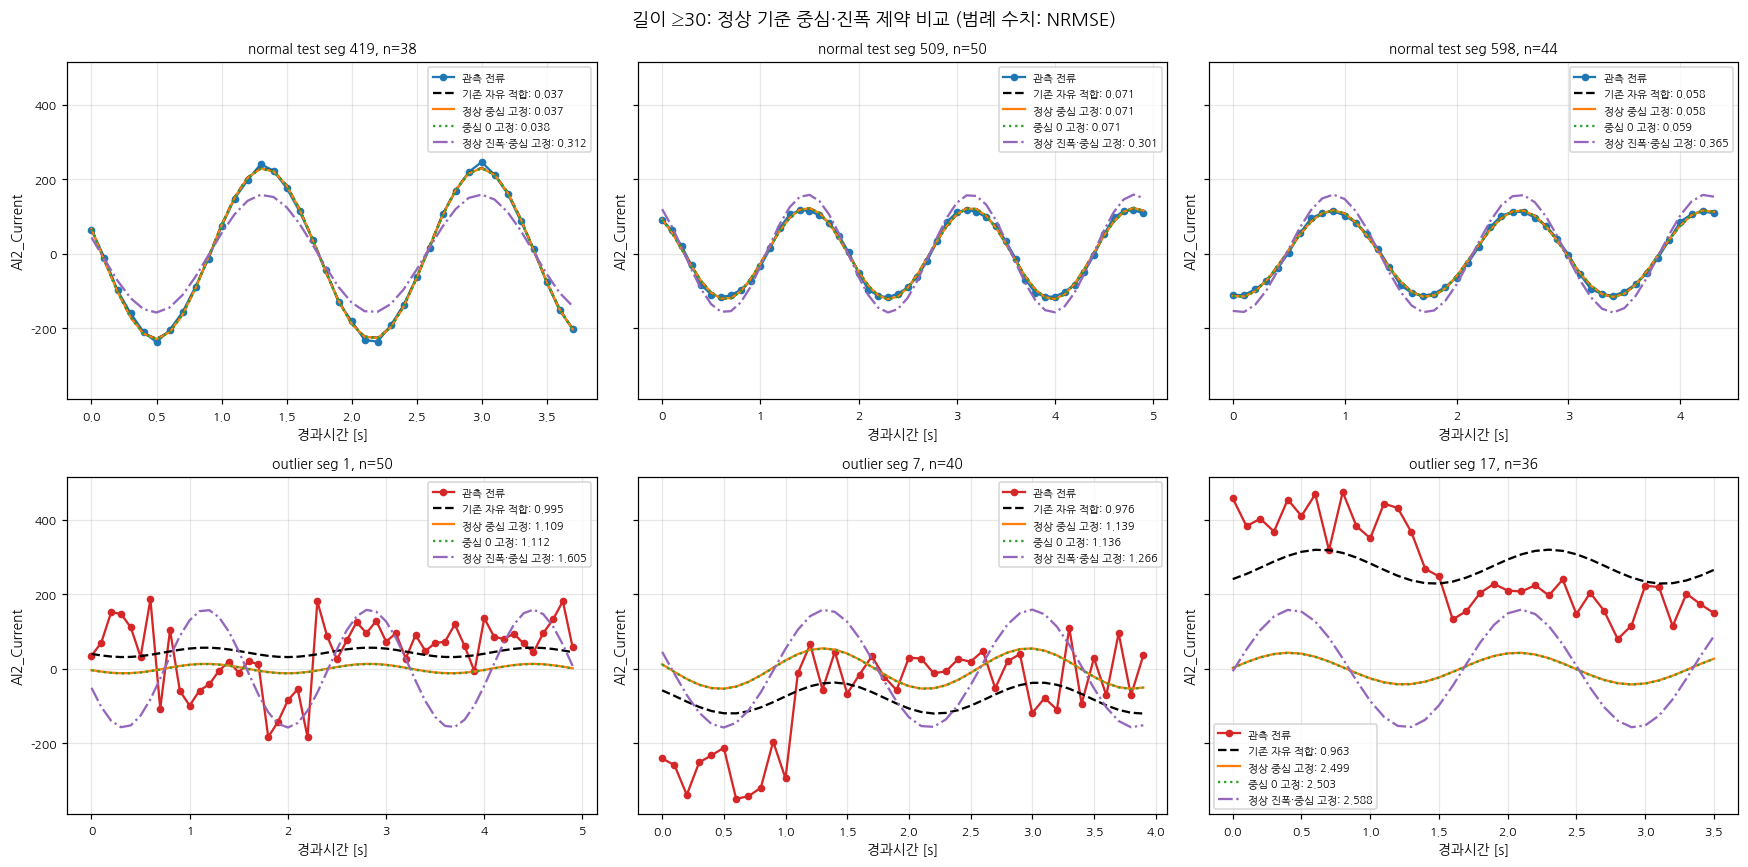

In [ ]:
fig, axes = plt.subplots(2,2,figsize=(14,8),sharex=True)
for ax,model in zip(axes.flat,CENTER_MODELS):
    for group,color in [("normal test",COLOR["normal"]),("outlier",COLOR["outlier"])]:
        sub = CENTER_FIT[(CENTER_FIT.model==model)&(CENTER_FIT.group==group)]
        ax.scatter(sub.n,sub.nrmse,s=22,alpha=.6,color=color,label=group)
    ax.set_title(CENTER_LABELS[model]);ax.set_xlabel("샘플 수 n")
    ax.set_ylabel("NRMSE (낮을수록 적합)");ax.legend()
fig.suptitle("정상 기준 파형 제약에 따른 잔차 — 작은 표본은 과적합에 주의")
plt.tight_layout();plt.show()

EXAMPLE_BINS = [("≤3",1,4),("4~5",4,6),("6~7",6,8),("8~10",8,11),
                ("11~14",11,15),("15~19",15,20),("20~29",20,30),("≥30",30,np.inf)]
for name, lower, upper in EXAMPLE_BINS:
    examples = {}
    for label in ["normal", "outlier"]:
        sub = F[(F.label == label) & (F.n >= lower) & (F.n < upper)].sort_values("t_start")
        if label == "normal": sub = sub[sub.t_start >= sine_split]
        indices = np.linspace(0, len(sub)-1, min(3, len(sub)), dtype=int)
        examples[label] = sub.iloc[indices]
    selected = pd.concat(examples.values())
    if selected.empty: continue
    all_values = []
    for row in selected.itertuples():
        g = SEG[row.label].loc[SEG[row.label].seg_id == row.seg_id]
        all_values.append(g.AI2_Current.to_numpy())
        all_values.extend(CENTER_PRED[(row.label,row.seg_id)].values())
    all_values = np.concatenate(all_values)
    low, high = all_values.min(), all_values.max()
    pad = max((high-low)*.05, 1.0)
    fig, axes = plt.subplots(2,3,figsize=(16,8),sharey=True,squeeze=False)
    for i,label in enumerate(["normal","outlier"]):
        rows = list(examples[label].itertuples())
        for j,ax in enumerate(axes[i]):
            if j >= len(rows): ax.set_visible(False); continue
            row = rows[j]
            g = SEG[label].loc[SEG[label].seg_id == row.seg_id]
            t = (g.TimeStamp-g.TimeStamp.iloc[0]).dt.total_seconds()
            ax.plot(t,g.AI2_Current,"o-",ms=4,color=COLOR[label],label="観測電流".replace("観測電流","관측 전류"))
            metrics = CENTER_FIT[(CENTER_FIT.label==label)&(CENTER_FIT.seg_id==row.seg_id)].set_index("model")
            for model,style,color in [("free","--","black"),("normal_center","-","#ff7f0e"),
                                      ("zero_center",":","#2ca02c"),("normal_template","-.","#9467bd")]:
                ax.plot(t,CENTER_PRED[(label,row.seg_id)][model],style,color=color,
                        label=f"{CENTER_LABELS[model]}: {metrics.loc[model,'nrmse']:.3f}")
            group = "normal test" if label=="normal" else "outlier"
            caution = " / 小標本: 판별 주의".replace("小標本","작은 표본") if row.n<=5 else ""
            ax.set_title(f"{group} seg {row.seg_id}, n={row.n}{caution}",fontsize=9)
            ax.set_ylim(low-pad,high+pad)
            ax.set_xlabel("경과시간 [s]");ax.set_ylabel("AI2_Current");ax.legend(fontsize=7)
    fig.suptitle(f"길이 {name}: 정상 기준 중심·진폭 제약 비교 (범례 수치: NRMSE)")
    plt.tight_layout();plt.show()


### 4-2. 비교 결과와 해석

정상 train 기준 중심값은 **0.5489**, 진폭 중앙값은 **158.3520**이다.
중심값은 진폭에 비해 작으며, 정상 중심 고정과 영점 고정 결과도 유사하다.
센서 단위 및 전처리는 별도 확인 대상이며 이 값만으로 실제 DC 전류를 단정하지 않는다.

| 모델 | 정상 test NRMSE 중앙값 | outlier NRMSE 중앙값 |
|---|---:|---:|
| 기존 자유 적합 | 0.069 | 0.947 |
| 정상 중심 고정 | 0.069 | 1.139 |
| 중심 0 고정 | 0.069 | 1.136 |
| 정상 진폭·중심 고정 | 0.318 | 1.765 |

정상 중심을 고정해도 정상 파형의 적합성은 거의 유지되며 outlier 잔차는 커졌다.
기존에 잘 맞던 outlier seg10(n=4)은 NRMSE **0.115 → 0.505**, R² **0.987 → 0.745**로
변했다. 자유로운 중심 이동이 짧은 이상 조각을 잘 맞게 만들 수 있다는 구체적 사례다.
반면 진폭까지 고정하면 정상의 부하·진폭 차이도 잔차에 반영되므로 형태와 진폭의 효과를
구분해야 한다. **정상 주기·중심을 고정하고 진폭·위상만 허용한 잔차가 유망하나, 채택은 보류한다.**

중심을 고정한 모델은 평균값을 자유롭게 맞추지 않으므로 NRMSE가 1보다 크거나 R²가 음수가
될 수 있다. 이는 평균값만 사용하는 예측보다 오차가 크다는 뜻이며 계산 오류가 아니다.
짧은 표본에서는 여전히 위상·진폭만으로 잘 맞는 경우가 있을 수 있고, 중심 고정만으로
판별 문제가 모두 해소되지는 않는다. 경보 임계와 길이별 오경보·미탐률은 03에서 평가해야 한다.


## 5. 현재 판단과 다음 단계 — 상·하부 진동

**전류:** 공통 주기·정상 중심을 고정한 잔차가 유망하다. 피처 채택과 경보 임계는 아직 결정하지 않는다.
현재 데이터 내 길이별 비교이며, 다른 날짜에 대한 일반화는 검증하지 못했다.
파일 라벨 기준 차이를 설비 고장이나 조기탐지 성능으로 확정하지 않는다.

**다음은 진동 분석이다.** 앞 FFT 결과를 출발점으로 상·하부 진동을 각각 확인한다.

1. 정상/이상에서 RMS·관측 주파수 대역·주기성이 어떻게 달라지는가?
2. 시간이 지나거나 세그먼트 길이가 달라져도 차이가 유지되는가?
3. 상·하부 진동이 함께 변하는지, 특정 채널에만 변화가 나타나는가?
4. 현재 ai0_rms·env_cv·ai0_ac1을 유지하거나 보완할 지표가 있는가?

진동은 전류의 고정 사인파 가정을 그대로 적용하지 않는다. 원시 파형과 시간·길이별 분포를
확인한 뒤 피처 후보를 정하고, 이후 03에서 규칙 기반 오류율을 평가한다.
